<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

## Keep Alive Code

In [ ]:
#import time
#while True:
#          print("Keeping Colab Active...")
#          time.sleep(500)  # Wait for 500 seconds before printing again

## Importing necessary libraries

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

import time
import random

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

In [ ]:
# to split the data into train and test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [ ]:
# importing SMOTE
from imblearn.over_sampling import SMOTE

# importing different functions to build models
import tensorflow as tf
from tensorflow import keras
from keras import backend
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.utils import plot_model
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# importing metrics
from sklearn import metrics
# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [ ]:
# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

## Loading the dataset

In [ ]:
# This is specific to my google colab environment
from google.colab import drive

drive.mount('/content/drive',force_remount = True)

FOLDER_PATH = '/content/drive/MyDrive/Colab_Notebooks/Bank_Churn_Project/'

data = pd.read_csv(FOLDER_PATH+"bank-1.csv")

Mounted at /content/drive


## Data Overview

###Displaying Head & Tail of the dataset

In [ ]:
#Head and Tail of the data
display(data.head())
display(data.tail())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,3,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.000,2,1,0,96270.640,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.610,1,1,1,101699.770,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.000,1,0,1,42085.580,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.310,2,1,0,92888.520,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.790,1,1,0,38190.780,0


### Displaying the shape of the dataset

In [ ]:
#Shape of the data
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 10000 rows and 14 columns.


* We see that the dataset has 10,000 Rows and 14 Columns

### Checking 10 random rows in the dataset

In [ ]:
data.sample(n=10, random_state=1)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9953,9954,15655952,Burke,550,France,Male,47,2,0.000,2,1,1,97057.280,0
3850,3851,15775293,Stephenson,680,France,Male,34,3,143292.950,1,1,0,66526.010,0
4962,4963,15665088,Gordon,531,France,Female,42,2,0.000,2,0,1,90537.470,0
3886,3887,15720941,Tien,710,Germany,Male,34,8,147833.300,2,0,1,1561.580,0
5437,5438,15733476,Gonzalez,543,Germany,Male,30,6,73481.050,1,1,1,176692.650,0
8517,8518,15671800,Robinson,688,France,Male,20,8,137624.400,2,1,1,197582.790,0
2041,2042,15709846,Yeh,840,France,Female,39,1,94968.970,1,1,0,84487.620,0
1989,1990,15622454,Zaitsev,695,Spain,Male,28,0,96020.860,1,1,1,57992.490,0
1933,1934,15815560,Bogle,666,Germany,Male,74,7,105102.500,1,1,1,46172.470,0
9984,9985,15696175,Echezonachukwu,602,Germany,Male,35,7,90602.420,2,1,1,51695.410,0


### Checking data types present in the dataset

In [ ]:
df = data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


* Three columns are of the "Object" type, two are of type "float" and the remaining nine are of type "Int".

### Statistical summary of the dataset

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.000,NaN,NaN,NaN,5000.500,2886.896,1.000,2500.750,5000.500,7500.250,10000.000
CustomerId,10000.000,NaN,NaN,NaN,15690940.569,71936.186,15565701.000,15628528.250,15690738.000,15753233.750,15815690.000
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.000,NaN,NaN,NaN,650.529,96.653,350.000,584.000,652.000,718.000,850.000
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.000,NaN,NaN,NaN,38.922,10.488,18.000,32.000,37.000,44.000,92.000
Tenure,10000.000,NaN,NaN,NaN,5.013,2.892,0.000,3.000,5.000,7.000,10.000
Balance,10000.000,NaN,NaN,NaN,76485.889,62397.405,0.000,0.000,97198.540,127644.240,250898.090
NumOfProducts,10000.000,NaN,NaN,NaN,1.530,0.582,1.000,1.000,1.000,2.000,4.000


**Key Customer Characteristics:**
* **Credit Score**: Ranges widely from 350 to 850, with an average score of 650.5. Half the customers have scores between 584 and 718.

* **Age**: Customers range from 18 to 92 years old, with an average age of approximately 39 years. The middle 50% of customers are between 32 and 44 years old.

* **Tenure:** Customers have been with the bank between 0 and 10 years, with an average tenure of 5 years.

* **Account Balance:** Balances vary significantly, from 0 up to nearly 251,000.
At least 25% of customers have a zero balance, while the median balance is $97,199, indicating a skew potentially due to the zero-balance accounts.

* **Number of Products:** Customers typically hold 1 or 2 bank products (with an average of 1.53). More than half of the customers hold only one product.

* **Estimated Salary:** Estimated salaries are distributed across a wide range (approx. $11.58 to 200,000). The median is close to the mean and distribution relatively uniform.


* **Credit Card Ownership:** About 70.6% of customers have a credit card with the bank.

* **Active Members:** The customer base is nearly evenly split, with 51.5% identified as active members.

* **Exited Status (Churn):** Approximately 20.4% of the customers in this dataset have closed their accounts (exited).

### Checking for missing values

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


### Checking for unique values

In [ ]:
df.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


In [ ]:
# Print the uniques values in Exited
print("Unique values in Exited:", np.sort(df['Exited'].unique()))

# Print the unique values in Geography
print("Unique values in Geography:", df['Geography'].unique())

# Print the unique values in Gender
print("Unique values in Gender:", df['Gender'].unique())

# Print the unique values in NumOfProducts
print("Unique values in NumOfProducts:", np.sort(df['NumOfProducts'].unique()))

# Print the unique values in Tenure
print("Unique values in Tenure:", np.sort(df['Tenure'].unique()))

Unique values in Exited: [0 1]
Unique values in Geography: ['France' 'Spain' 'Germany']
Unique values in Gender: ['Female' 'Male']
Unique values in NumOfProducts: [1 2 3 4]
Unique values in Tenure: [ 0  1  2  3  4  5  6  7  8  9 10]


* There are quite a few unique columns
* Exited has two unique values - 0, 1
* Geography has 3 unique values - France, Germany, Spain
* Gender has 2 unique values - Male, Female
* NumOfProducts has 4 unique values

### Checking for duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

* No duplicate rows found in the dataset

### Dropping columns

In [ ]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

### Checking for data imbalance

Class Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage Distribution:
Exited
0   79.630
1   20.370
Name: proportion, dtype: float64


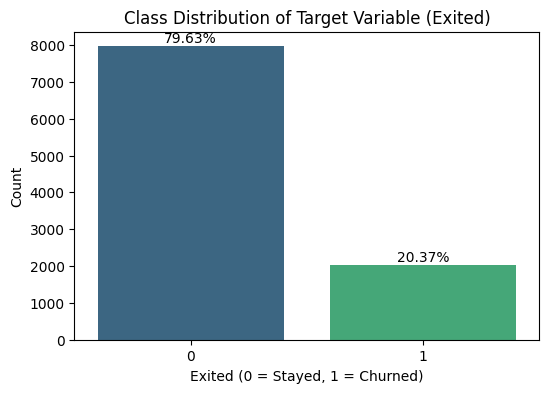

In [ ]:
# 1. Check value counts
class_counts = df['Exited'].value_counts()
print("Class Distribution:")
print(class_counts)

# 2. Percentage distribution
class_percentages = df['Exited'].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
print(class_percentages)

# 3. Plot class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution of Target Variable (Exited)")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Count")
for i, val in enumerate(class_counts.values):
    plt.text(i, val + 100, f'{class_percentages[i]:.2f}%', ha='center')
plt.show()

* Data is imbalanced: almost an 80-20 split between customers who stayed and exited.
* If this imbalance is not handled then, we might get poor recall or F1-scores when the model is trained.
* The model might bias towards predicting customers who stayed as it seems more of those.

## Exploratory Data Analysis

### Univariate Analysis

In [ ]:
#Function to plot both histogram and boxplot

def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=True, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=True, ax=ax_hist2
    )  # For histogram

    # Calculate and plot mean and median only if the feature is numeric
    if pd.api.types.is_numeric_dtype(data[feature]):
      ax_hist2.axvline(
          data[feature].mean(), color="green", linestyle="--"
      )  # Add mean to the histogram
      ax_hist2.axvline(
          data[feature].median(), color="blue", linestyle="-"
      )  # Add median to the histogram
    else:
      #add mode
      ax_hist2.axvline(
          data[feature].mode()[0], color="blue", linestyle="-"
      )

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on CreditScore

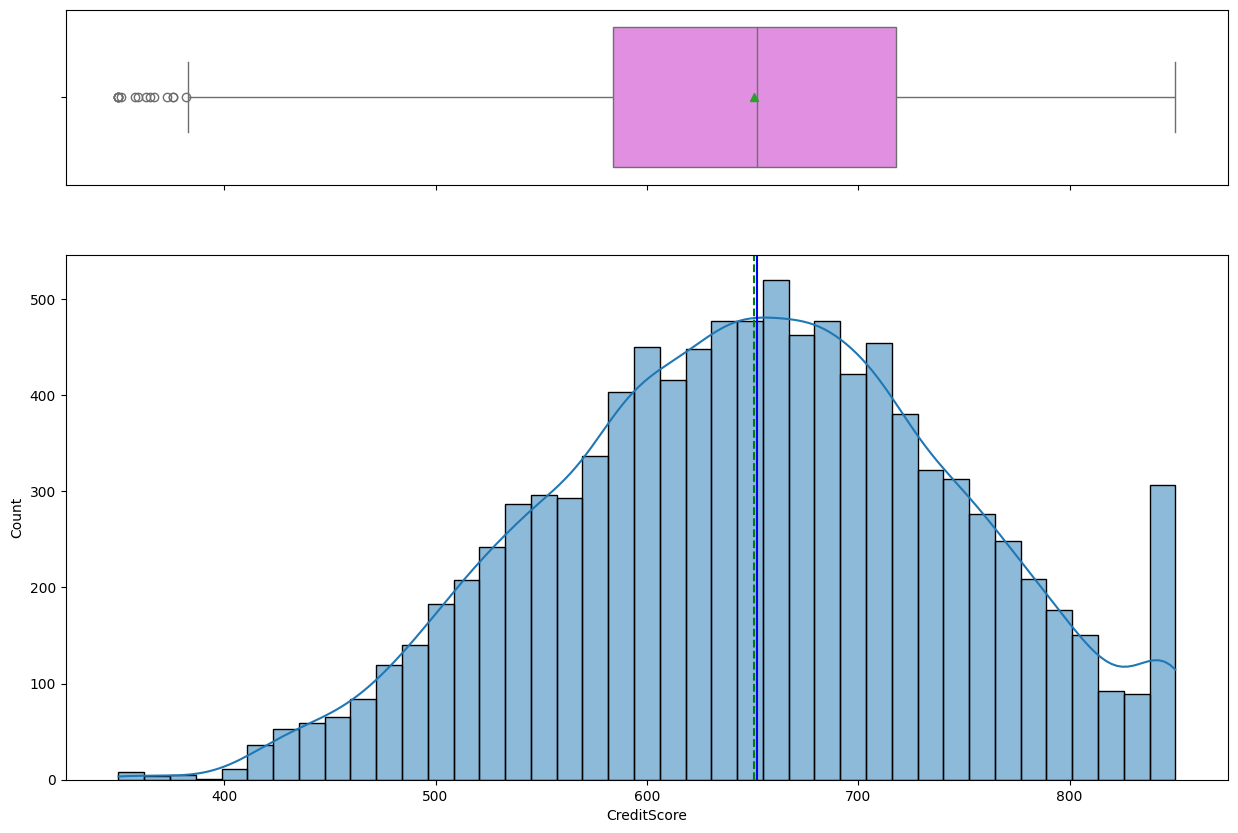

In [ ]:
histogram_boxplot(df, 'CreditScore')

* The distribution is approximately bell-shaped (with a slight left skew).
* The bulk of the credit scores are around the middle range.
* The credit scores range between around 350 to 850.
* The Interquartile Range (IQR), shows that the middle 50% of customers have credit scores roughly between ~580 and ~720
* The boxplot clearly identifies several outliers with very low credit scores (below approximately 400). These are scores that fall significantly below the typical range for the majority of customers.
* There is a noticeable spike in credit scores that are exactly 850, indicating that a significant number of customers have top score.

#### Observations on Age

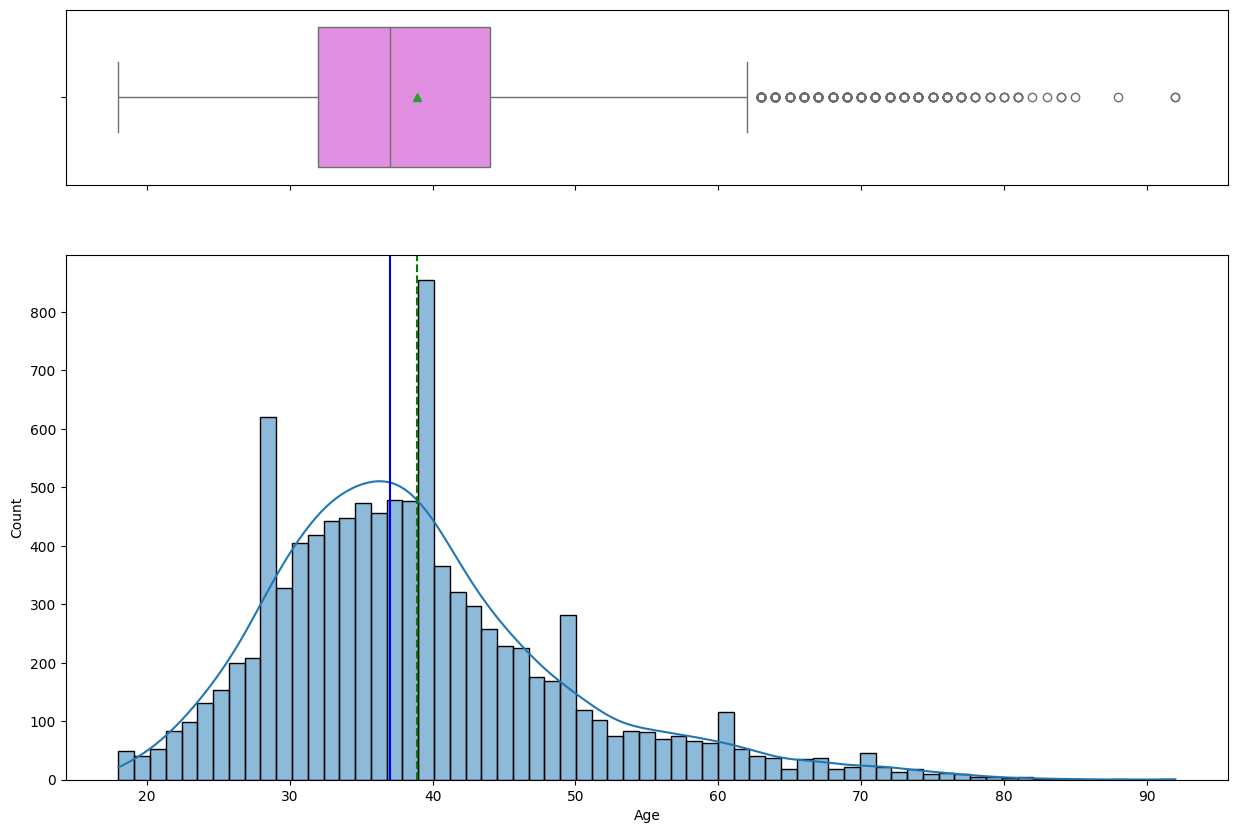

In [ ]:
histogram_boxplot(df, 'Age')

* The distribution is right skewed. This means a significant portion of customers are in the younger to middle age range.
* The customer age ranges from 18 to over 90 years
* IQR, indicates that middle 50% of customers are aged between approximately 32 and 44 years.
* The boxplot indicates several outliers on the higher end of the age scale.

#### Observations on Balance

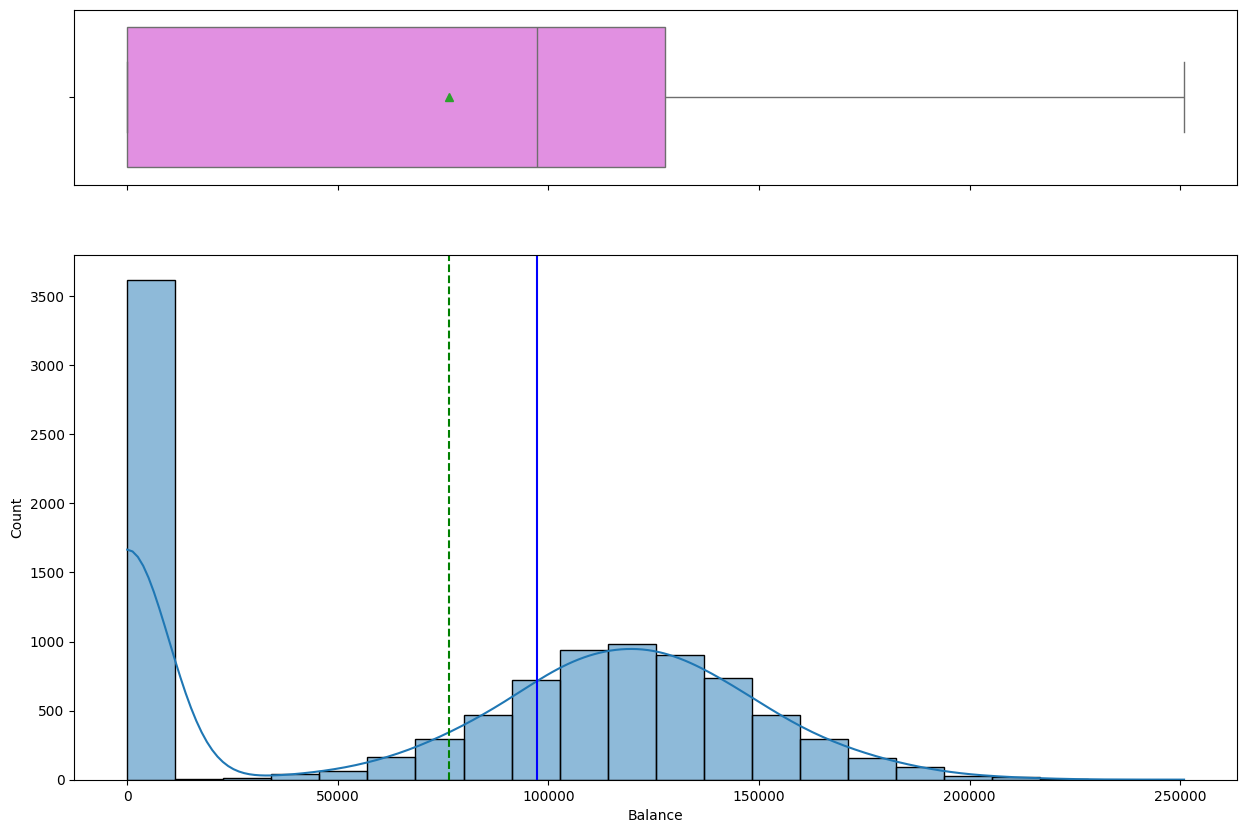

In [ ]:
histogram_boxplot(df, 'Balance')

* The distribution is right skewed.
* There is a huge spike near zero, indicating that many accounts have very low or no balance.
* There are two peaks - the one near zero and another between approximately 120,000 & 130,000.
* The mean is pulled up high due to some high balance values (mean > median).
* No visible outliers observed.

#### Observations on Estimated Salary

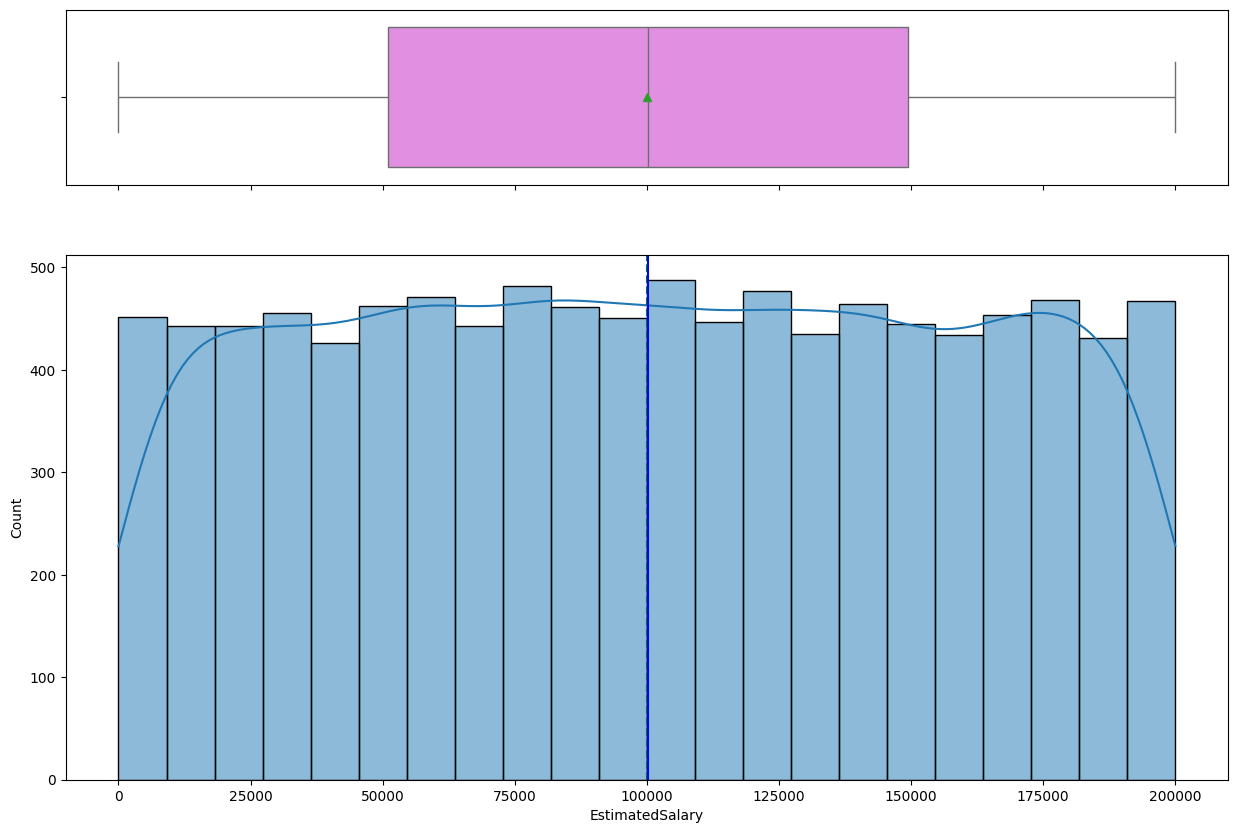

In [ ]:
histogram_boxplot(df, 'EstimatedSalary')

* The distribution is uniform and symmetric between (0 and 200,000)
* The mean and median are almost identical around 100,000

#### Observations on Exited

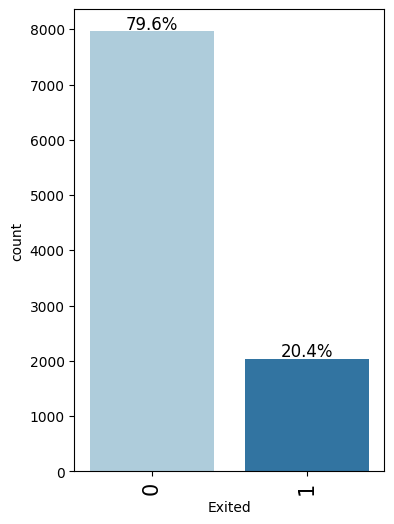

In [ ]:
labeled_barplot(df, 'Exited', perc=True)

* 20% of the customer show that they have exited and needs more analysis.

#### Observations on Geography

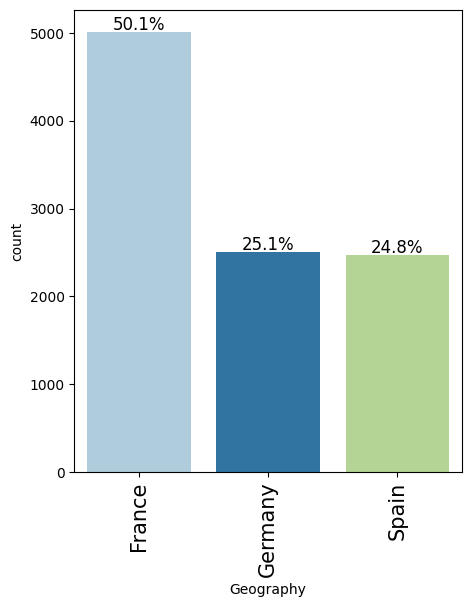

In [ ]:
labeled_barplot(df, 'Geography', perc=True)

* Approximately 50% of the customers are from France, 25% from Germany and Spain each.

#### Observations on Gender

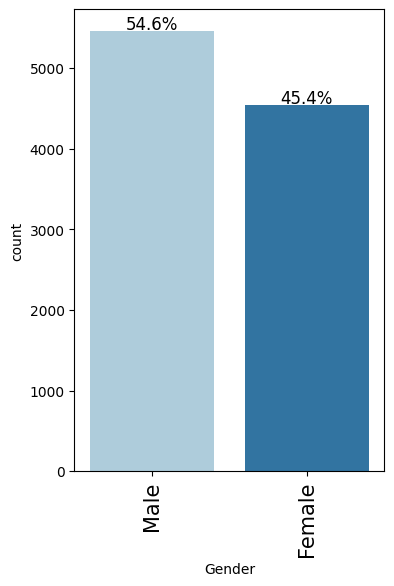

In [ ]:
labeled_barplot(df, 'Gender', perc=True)

* 54.6% of customers are males and 45.4% are females.

#### Observations on Tenure

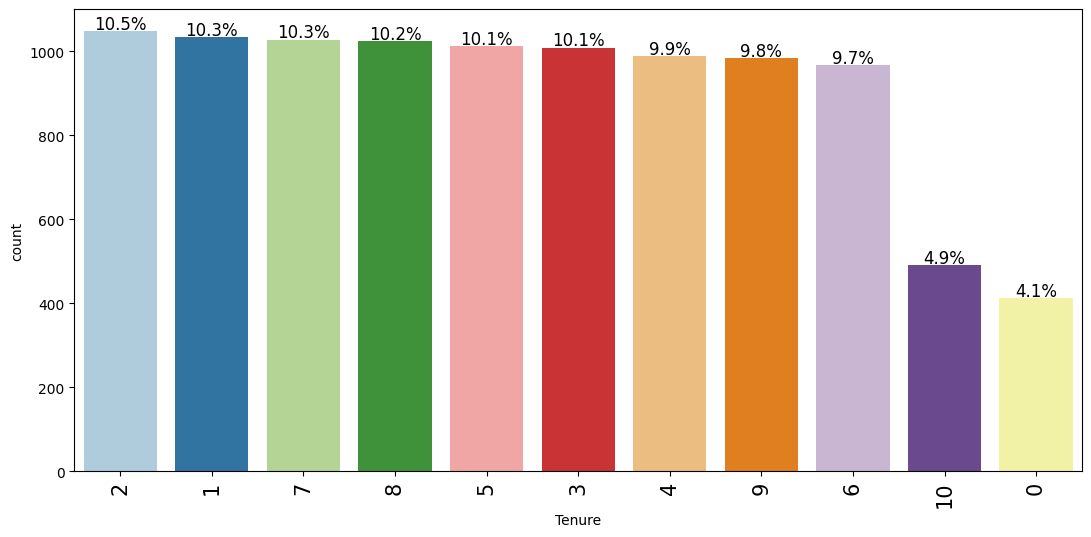

In [ ]:
labeled_barplot(df, 'Tenure', perc=True)

* 4.1% of customers either did not take loans or finished repaying.
* Tenures of 1 to 9 has almost equal number of customers.

#### Observations on Number of Products

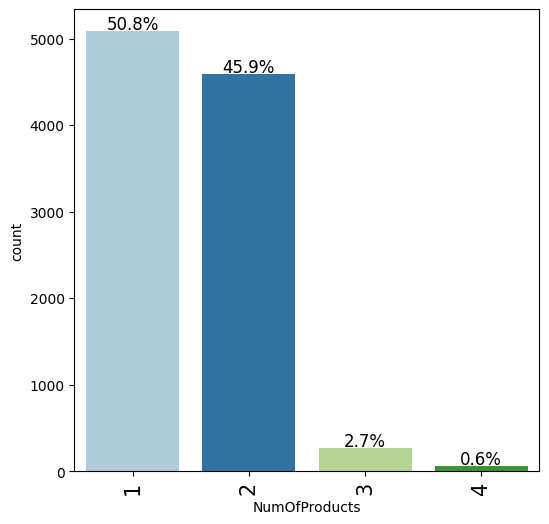

In [ ]:
labeled_barplot(df, 'NumOfProducts', perc=True)

* 50.8% of customers have availed 1 product and 45.9% availed 2 products.
* The number of customers that have availed 3 or 4 products.

#### Observations on has Credit Card

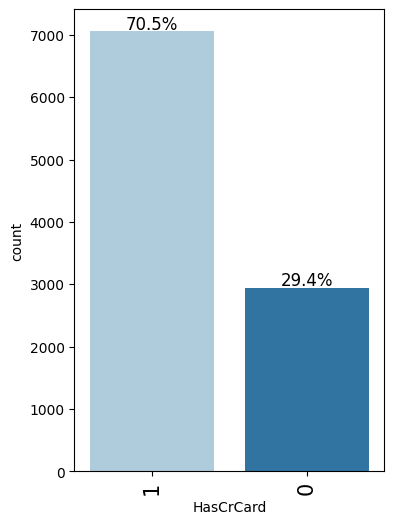

In [ ]:
labeled_barplot(df, 'HasCrCard', perc=True)

* 29.4% of customers do not have credit cards.

#### Observations on Active Member

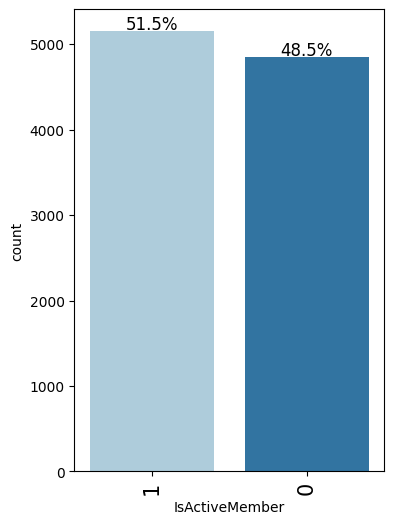

In [ ]:
labeled_barplot(df, 'IsActiveMember', perc=True)

* Almost 50% customers are not active members.

### Bivariate Analysis

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
### function to boxplot distributions wrt target

def distribution_boxplot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(1,2 , figsize=(12, 5))

    axs[0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[0], palette="gist_rainbow")

    axs[1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Correlation (Heat) Map

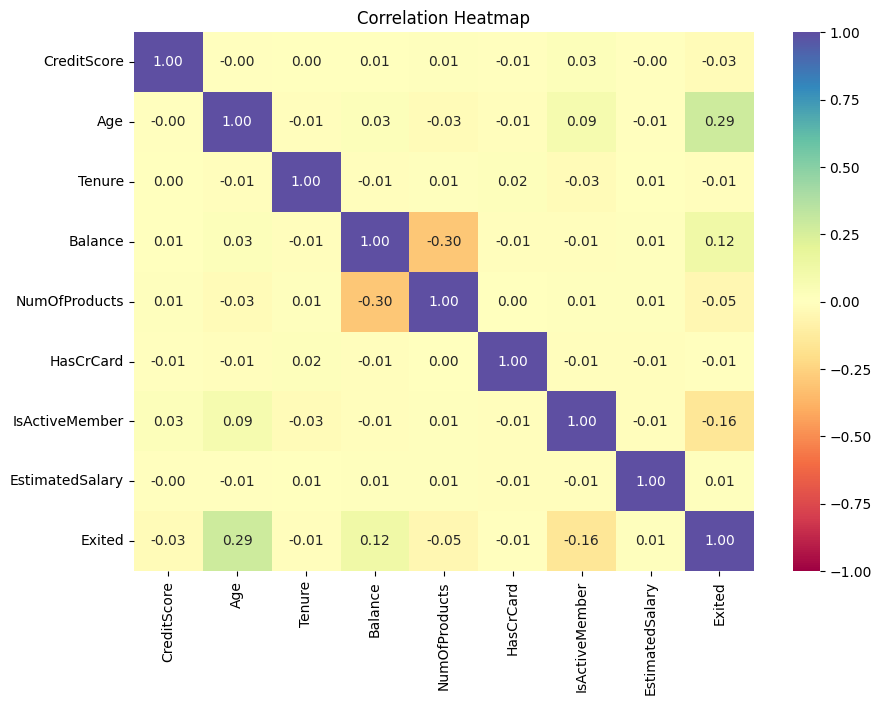

In [ ]:
# plot correlation on numeric columns
corr =  df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

plt.title("Correlation Heatmap")
plt.show()

* No strong correlation is observed in the dataset.
* Age is observed to have 0.29 correlation with Exited

#### Exited vs Geography

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


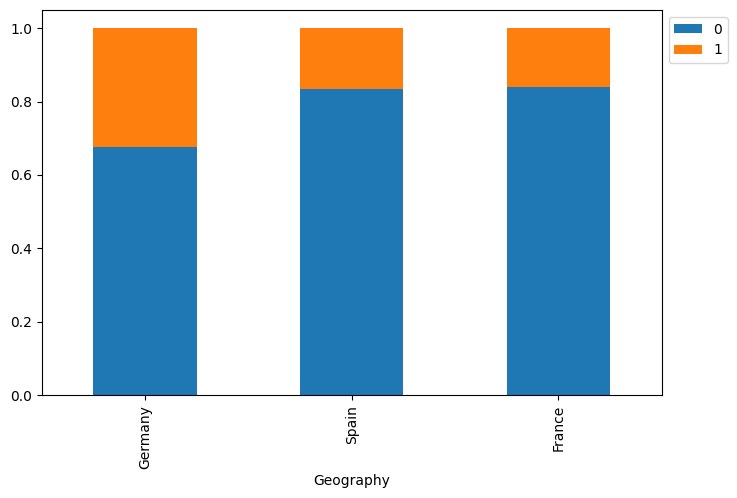

In [ ]:
stacked_barplot(df, 'Geography', 'Exited')

* Germany has more number of customers that have exited (almost 35%)
* France & Spain have very similar numbers for customers that have exited (almost 15%)

#### Exited vs Gender

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


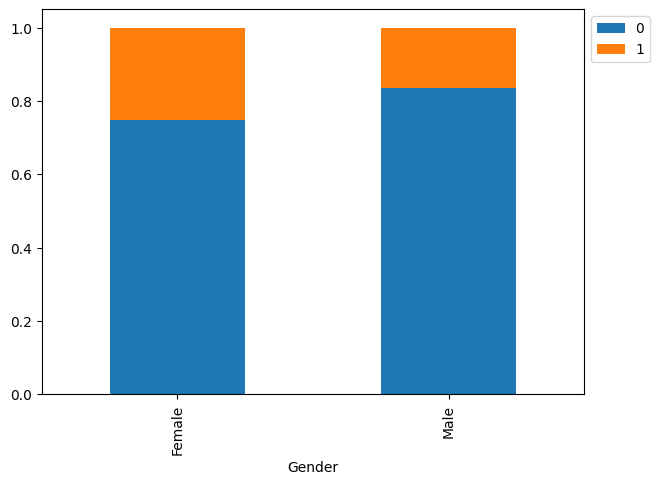

In [ ]:
stacked_barplot(df, 'Gender', 'Exited')

* Female customers (approx. 25%) seem to have exited more than Male customers (approx. 15%)

#### Exited vs has Credit Card

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


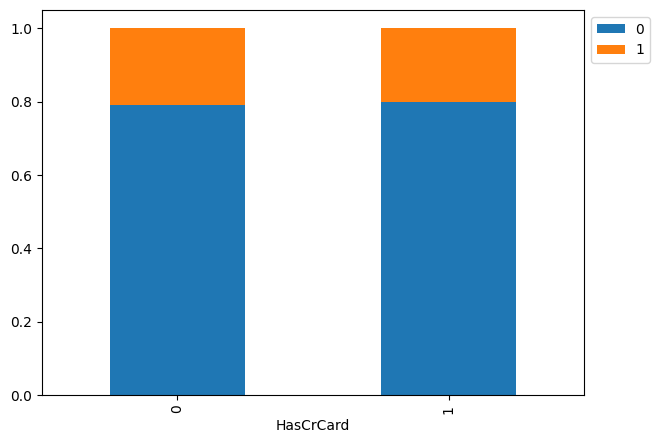

In [ ]:
stacked_barplot(df, 'HasCrCard', 'Exited')

* The percentage of customers (almost 20%) that exited were the same irrespective of having a credit card.

Exited vs Is Active Member

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


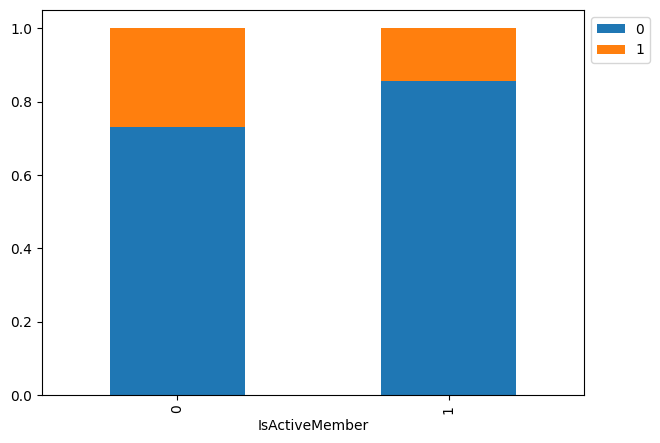

In [ ]:
stacked_barplot(df, 'IsActiveMember', 'Exited')

* Inactive customers had more exits (almost 25%) than active customers (almost 15%)

#### Exited vs Credit Score

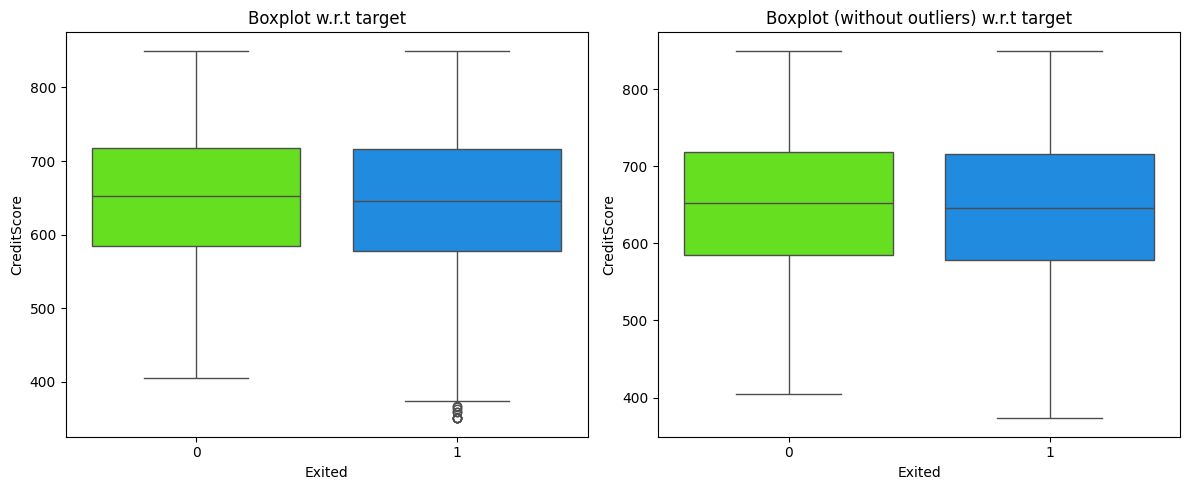

In [ ]:
distribution_boxplot_wrt_target(df, 'CreditScore', 'Exited')

* IQR is similar for bothe groups
* Outliers are present in the exited group (left plot) - a cluster of very low credit scores
* With the outliers removed, the visual difference is minimal between the plots. This might suggest that credit score alone might not be a strong predictor of exit.

Exited vs Age

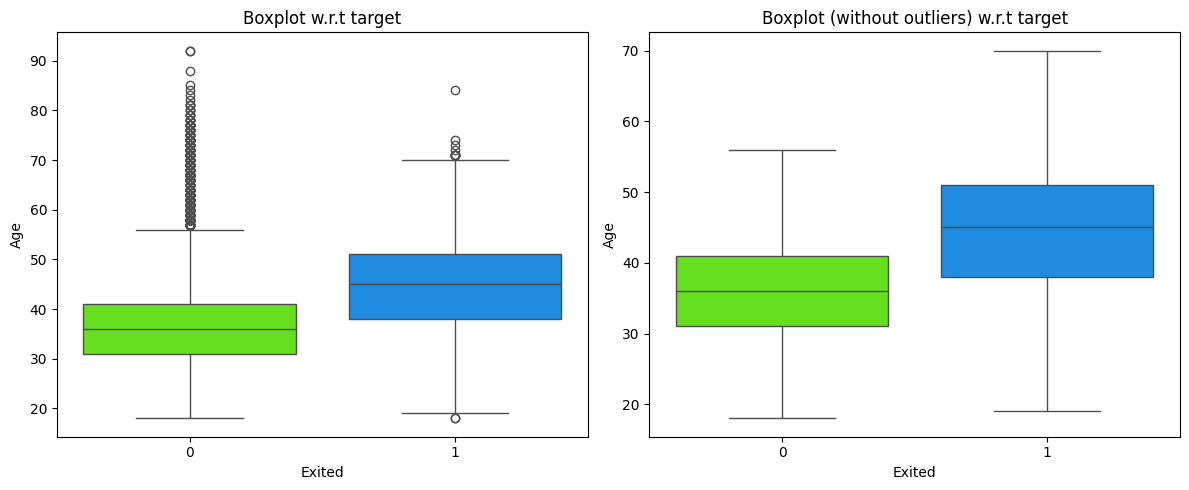

In [ ]:
distribution_boxplot_wrt_target(df, 'Age', 'Exited')

* The median age of customers who exited is higher than those that stayed in both plots - with or without outliers.
* Large numbers of outliers are present in the non-exited customer group (between the ages of 60 and 90+).
* With the outliers removed, the median age is more pronounced.
* The customers who stayed clustered around the age range of 30s to 40s, while the customers who exited clustered around the age range of 40s to 50s.
* Age can be seen to have an impact on exiting - with older customers more likely to exit.

#### Exited vs Tenure

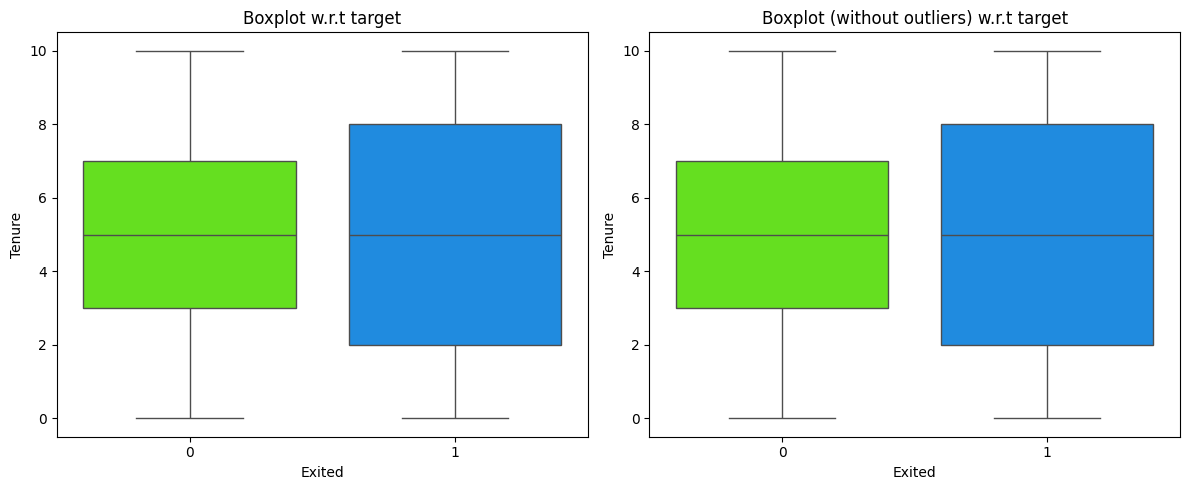

In [ ]:
distribution_boxplot_wrt_target(df, 'Tenure', 'Exited')

* There is a lack of outliers observed in the plots.
* Tenure does not show a strong signal in indicating the customers exit.



#### Exited vs Balance

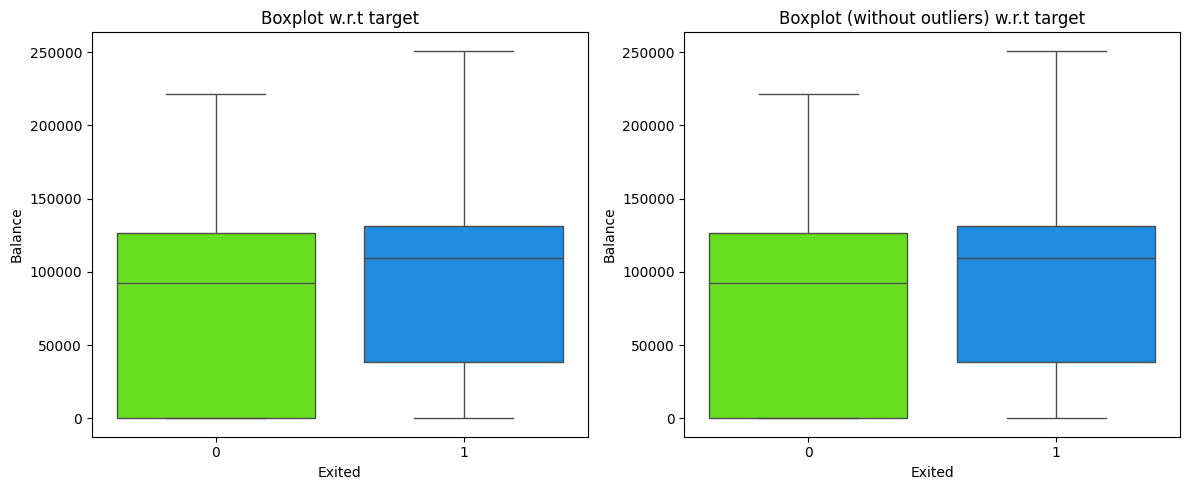

In [ ]:
distribution_boxplot_wrt_target(df, 'Balance', 'Exited')

* There is a lack of outliers observed in the plots.
* Balance does not show a strong signal in indicating the customers exit.

#### Exited vs Number of Products

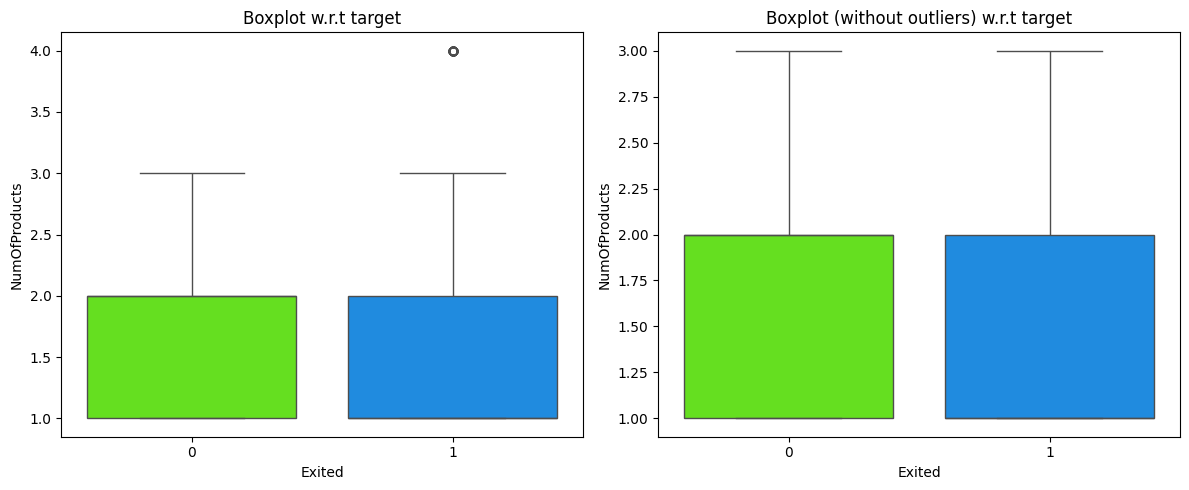

In [ ]:
distribution_boxplot_wrt_target(df, 'NumOfProducts', 'Exited')

* There is an outlier observed in the plot.
* Number of products does not show a strong signal in indicating the customers exit.

#### Exited vs Estimated Salary

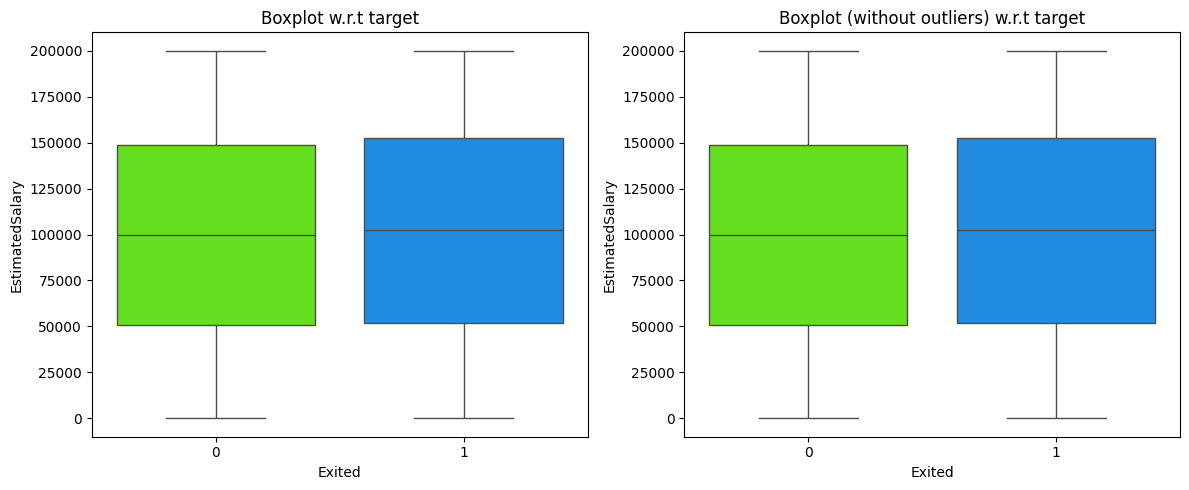

In [ ]:
distribution_boxplot_wrt_target(df, 'EstimatedSalary', 'Exited')

* There is a lack of outliers observed in the plots.
* Estimated Salary does not show a strong signal in indicating the customers exit.

## Data Preprocessing

#### Splitting into Train, Validation and Test

In [ ]:
# Drop the Exited column
X = df.drop(['Exited'], axis = 1)
y = df['Exited']

In [ ]:
# define RANDOM_STATE
RANDOM_STATE = 42

# Splitting data into training (60%), validation (20%) and test (20%) set:

# first we split data into 2 parts, say temporary (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# then we split the temporary set into train (75%) and validation (25%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

### Shape of the split dataset

In [ ]:
# Create a dictionary for dataset shapes
shape_data = {
    "Dataset": ["Training Set", "Validation Set", "Testing Set"],
    "Shape": [X_train.shape, X_val.shape, X_test.shape]
}

# Create a DataFrame for class distributions
class_dist = {
    "Training Set": y_train.value_counts(normalize=True).round(4),
    "Validation Set": y_val.value_counts(normalize=True).round(4),
    "Testing Set": y_test.value_counts(normalize=True).round(4)
}
class_dist_df = pd.DataFrame(class_dist)

# Convert shape tuple to a string for display
shape_df = pd.DataFrame(shape_data)
shape_df["Shape"] = shape_df["Shape"].astype(str)

# Transpose class distribution to match the shape table format
class_dist_df = class_dist_df.T.reset_index().rename(columns={"index": "Dataset"})

# Merge both tables
final_df = pd.merge(shape_df, class_dist_df, on="Dataset", how="left")

# Display the final table
print("\nSplit Dataset Overview:")
print(final_df.to_string(index=False))


Split Dataset Overview:
       Dataset      Shape     0     1
  Training Set (6000, 10) 0.796 0.204
Validation Set (2000, 10) 0.796 0.203
   Testing Set (2000, 10) 0.796 0.203


### Dummy Variable Creation

In [ ]:
#List the object type variables in df
cat_cols = X.select_dtypes(include=['object']).columns
cat_cols

Index(['Geography', 'Gender'], dtype='object')

In [ ]:
# Encode 'Geography' and 'Gender' in Training, Validation and Testing splits
# And convert them to float.
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True).astype(float)

X_val = pd.get_dummies(X_val, columns=cat_cols, drop_first=True).astype(float)

X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True).astype(float)

print(X_train.shape, X_val.shape, X_test.shape)

#print(X_train)

(6000, 11) (2000, 11) (2000, 11)


### Data Normalization

* Scale all the numeric values to bring them to the same scale

In [ ]:
#List all the numeric columns
num_cols = ["CreditScore","Age","Tenure","Balance","EstimatedSalary"]

#Instance of the standard scaler
sc = StandardScaler()

X_train[num_cols] = sc.fit_transform(X_train[num_cols])
X_val[num_cols] = sc.transform(X_val[num_cols])
X_test[num_cols] = sc.transform(X_test[num_cols])

### Missing value treatment

* Previously it was observed that no values were missing and hence we can skip this step.

## Model Building

### Model Evaluation Criterion

* **F1-score** would have been the best metric to be evaluated.
  * **False negatives** (FN) could be expensive and might lose a retention chance.
  * **False positives** (FP) might lead to unnecessary efforts, but less costly.
  * As the models were built, F1-scores were seen to be flat lines since it is a harmonic mean. We will choose a different metric.
* Customer churn is often imbalanced and hence Accuracy would be the wrong metric.
* Precision and Recall too could be considered as other candidates.
* In our case **we will choose Recall** (to measure true positives and minimize costlier false negatives)


### Function for plotting confustion matrix

In [ ]:
def make_confusion_matrix(actual_targets, predicted_targets):
    """
    To plot the confusion_matrix with percentages

    actual_targets: actual target (dependent) variable values
    predicted_targets: predicted target (dependent) variable values
    """
    cm = confusion_matrix(actual_targets, predicted_targets)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(cm.shape[0], cm.shape[1])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# Blank dataframes to store Recall Scores
train_scores_df = pd.DataFrame(columns=["Recall"])
val_scores_df = pd.DataFrame(columns=["Recall"])
test_scores_df = pd.DataFrame(columns=["Recall"])

### Neural Network with SGD Optimizer

In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# Initialize the neural network with SGD Optimizer
model_sgd = Sequential()

# Add an input layer with 128 neurons and Relu as the activation function
model_sgd.add(Dense(units=128, activation='relu', input_shape=(X_train.shape[1],)))

# Add an hidden layer with 64 neurons and Relu as the activation function
model_sgd.add(Dense(units=64, activation='relu'))

# Add an output layer with 1 neuron and Sigmoid as the activation function
# as this is a binary classification problem
model_sgd.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# Use SGD as the optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

#Choose Precision, Recall and F1 score as the metrics
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

# Compile the model with loss function of binary cross entropy and F1score as the metric
model_sgd.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)


In [ ]:
model_sgd.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_sgd = model_sgd.fit(
X_train, y_train,
batch_size=32,
validation_data=(X_val,y_val),
epochs=100,
verbose=1
)

end=time.time()

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - f1_score: 0.3364 - loss: 0.7325 - precision: 0.1609 - recall: 0.5011 - val_f1_score: 0.3382 - val_loss: 0.6607 - val_precision: 0.1626 - val_recall: 0.1474
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - f1_score: 0.3364 - loss: 0.6402 - precision: 0.1810 - recall: 0.0726 - val_f1_score: 0.3382 - val_loss: 0.5990 - val_precision: 0.4000 - val_recall: 0.0049
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - f1_score: 0.3364 - loss: 0.5853 - precision: 0.7231 - recall: 0.0025 - val_f1_score: 0.3382 - val_loss: 0.5607 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - f1_score: 0.3364 - loss: 0.5508 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_f1_score: 0.3382 - val_loss: 0.5362 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - f1_score: 0.3364 - loss: 0.5286 - precision: 0.0000e+00 - recall: 0.0000e+00 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  127.89241433143616


#### Plotting Training & Validation Loss

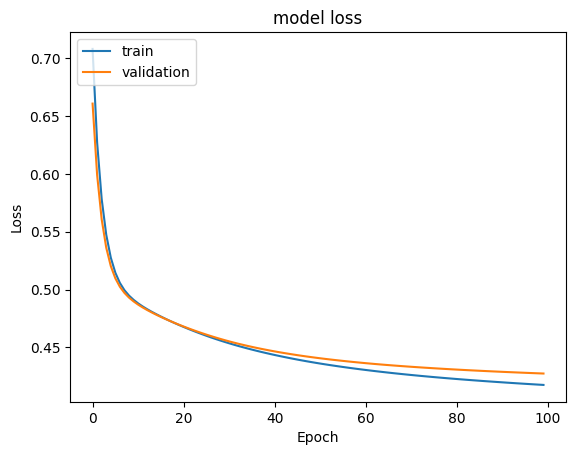

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_sgd.history['loss'])
plt.plot(history_sgd.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

* Both losses decrease steadily -indicating that the model is learning over time — the optimizer is effectively minimizing the loss.

* No signs of overfitting as the validation loss follows the training loss closely, without diverging.

* Smooth convergence as the losses flatten out towards the end, suggesting the model has nearly converged.



#### Plotting the Precision, Recall and F1 Scores

In [ ]:
def plot_metrics(history, metrics=["precision", "recall", "f1_score"]):
    """
    Plots training and validation metrics over epochs.

    Parameters:
    - history: Keras History object (e.g., history.history)
    - metrics: List of metric names to plot (default: ["precision", "recall", "f1_score"])
    """
    num_metrics = len(metrics)
    plt.figure(figsize=(5 * num_metrics, 4))

    for i, metric in enumerate(metrics):
        plt.subplot(1, num_metrics, i + 1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Validation')
        plt.title(f'Model {metric.replace("_", " ").title()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.replace("_", " ").title())
        plt.legend()

    plt.suptitle('Training and Validation Metrics over Epochs', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

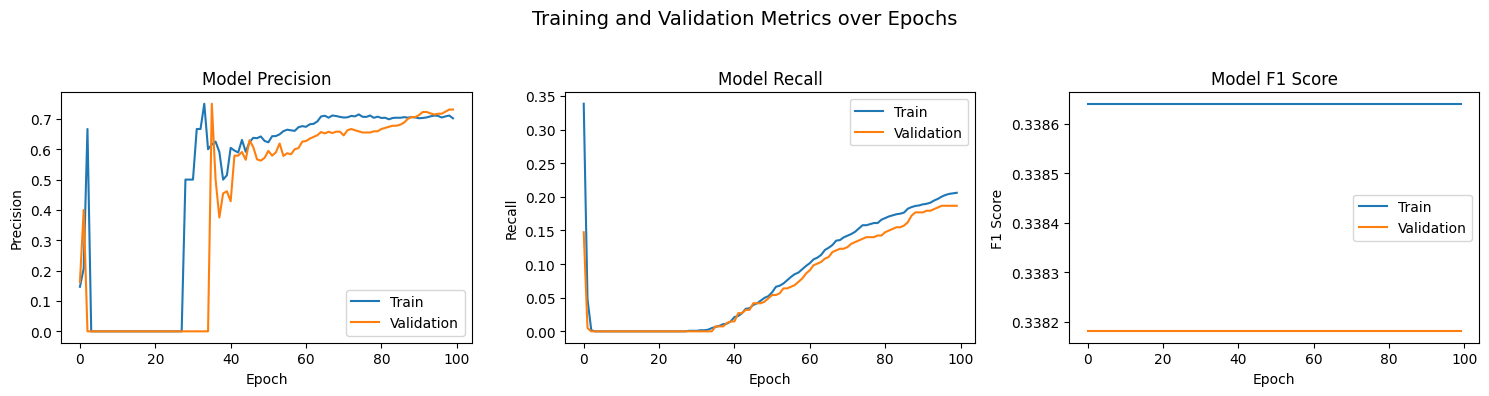

In [ ]:
plot_metrics(history_sgd, metrics=["precision", "recall", "f1_score"])

**Precision Metric - Improves well**
* Starts being erratic and then sabilizes after about 40 epochs for both training and validation data.
* The mode seems to be improving in its positive predictions.

**Recall Metric - Very poor**
* Starts near zero, rises slowly and plateaus around 0.2 for training and 0.18 for validation even after 100 epochs.
* The model seems to be missing most of the action positives.
* This could be the reason the F1 score remains low.

**F1 Metric - Flat and Low**
* F1 metric is quite low (though the delta is less between the training and validation sets)
* The model has underfit and has not learnt any meaningful patterns.
* The flat lines suggest that the model's ability to distinguish between the classes (in terms of precision and recall) did not improve over time.

In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_sgd.predict(X_train)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_sgd.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
model_name = "NN with SGD"

train_scores_df.loc[model_name] = recall_score(y_train, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      4777
           1       0.70      0.21      0.32      1223

    accuracy                           0.82      6000
   macro avg       0.76      0.59      0.61      6000
weighted avg       0.80      0.82      0.78      6000



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      1593
           1       0.73      0.19      0.30       407

    accuracy                           0.82      2000
   macro avg       0.78      0.58      0.60      2000
weighted avg       0.81      0.82      0.78      2000



#### Confusion Matrix

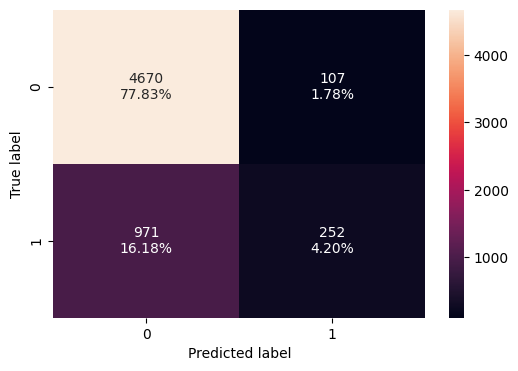

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train, y_train_pred)

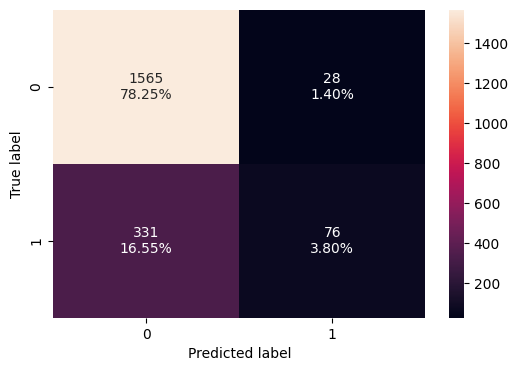

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

* SGD Optimizer is observed to have very poor performance for both training and validation datasets.

## Model Performance Improvement

### Neural Network with Adam Optimizer

In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
#Initializing the neural network
model_ao = Sequential()

#Code to add an input layer with 128 neurons
model_ao.add(Dense(128,activation='relu',kernel_initializer='he_normal', input_dim = X_train.shape[1]))

#Code to add an hidden layer with 64 neurons and relu as activation function
model_ao.add(Dense(64,activation='relu',kernel_initializer='he_normal'))

#Code to add an hidden layer with 64 neurons and relu as activation function
model_ao.add(Dense(64,activation='relu',kernel_initializer='he_normal'))


#Code to add a output layer with 1 neuron and sigmoid as activation function
model_ao.add(Dense(1, activation = 'sigmoid'))

In [ ]:
#Code to use Adam as the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#Choose Precision, Recall and F1 score as the metric
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

# Compile the model with loss function of binary cross entropy and F1score as the metric
model_ao.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)

In [ ]:
model_ao.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,017 (54.75 KB)

 Trainable params: 14,017 (54.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_ao = model_ao.fit(
X_train, y_train,
batch_size=32,
validation_data=(X_val,y_val),
epochs=100,
verbose=1
)

end=time.time()

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - f1_score: 0.3364 - loss: 0.7133 - precision: 0.3032 - recall: 0.2236 - val_f1_score: 0.3382 - val_loss: 0.4205 - val_precision: 0.6369 - val_recall: 0.2629
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - f1_score: 0.3364 - loss: 0.4019 - precision: 0.6600 - recall: 0.3082 - val_f1_score: 0.3382 - val_loss: 0.4078 - val_precision: 0.6814 - val_recall: 0.3415
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - f1_score: 0.3364 - loss: 0.3834 - precision: 0.6767 - recall: 0.3759 - val_f1_score: 0.3382 - val_loss: 0.3956 - val_precision: 0.6996 - val_recall: 0.3833
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - f1_score: 0.3364 - loss: 0.3682 - precision: 0.7089 - recall: 0.4069 - val_f1_score: 0.3382 - val_loss: 0.3886 - val_precision: 0.6947 - val_recall: 0.3857
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - f1_score: 0.3364 - loss: 0.3580 - precision: 0.7238 - recall: 0.4425 - val_f1_score: 0.3382 - val_los

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  180.23850798606873


#### Plotting Training and Validation Loss

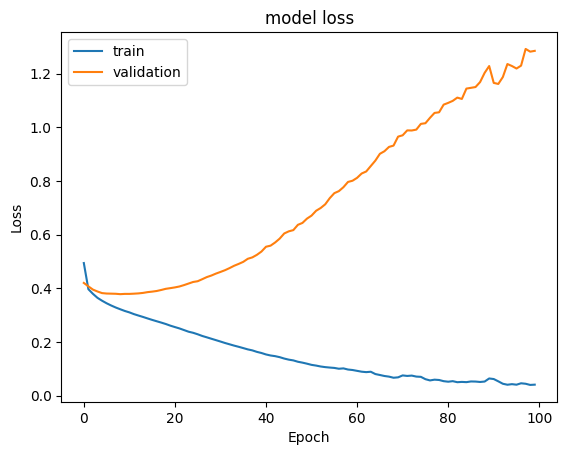

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_ao.history['loss'])
plt.plot(history_ao.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

* Training loss decreases smoothly and approaches zero - indicating that the model is fitting the training data well.
* Validation loss initially drop slightly and then increases to a higher value - indicating overfitting too early.

#### Plotting the Precision, Recall and F1 Scores

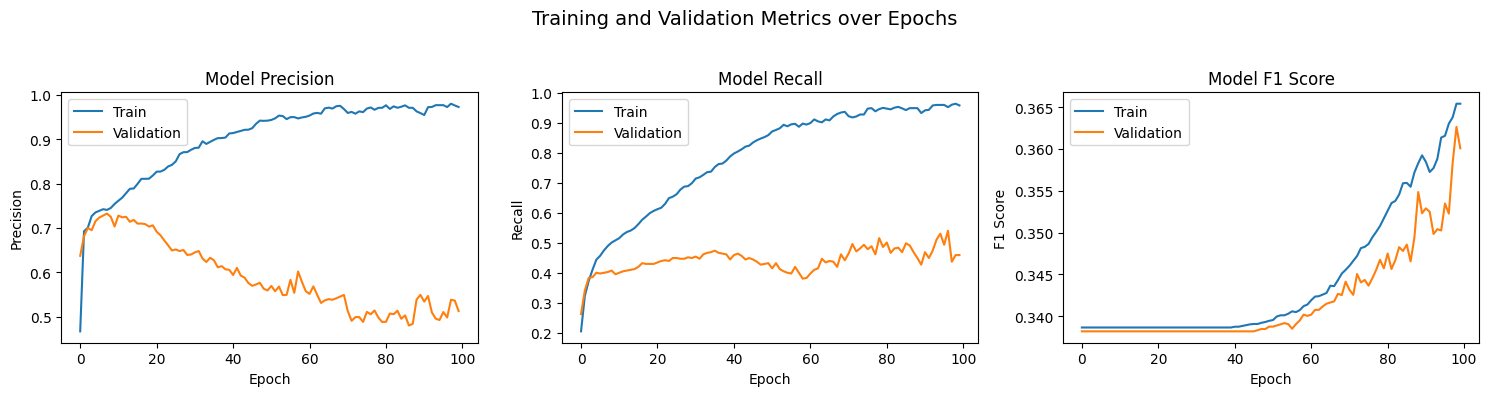

In [ ]:
plot_metrics(history_ao, metrics=["precision", "recall", "f1_score"])

**Precision Metric - Maybe overfitting**
* Training precision steadily approaches 1, while, the validation precision peaks and then declines before stabilizing a little.
* Model seems to be learning,but, generalization is dropping for validation data (maybe due to overfitting)

**Recall Metric - Poor recall on validation**
* Training recall steadily approaches 1, while the, validation recall plateaus around 0.5.
* Limited generalization is seen with probable overfitting

**F1 Metric - Low generalization**
* Training and Validation F1 scores both show increases after about 50 epochs.
* The gap between the two F1 scores indicate that the model is not generalizing well.

In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_ao.predict(X_train)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_ao.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with Adam"

train_scores_df.loc[model_name] = recall_score(y_train, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4777
           1       0.95      0.94      0.95      1223

    accuracy                           0.98      6000
   macro avg       0.97      0.96      0.97      6000
weighted avg       0.98      0.98      0.98      6000



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1593
           1       0.51      0.46      0.48       407

    accuracy                           0.80      2000
   macro avg       0.69      0.67      0.68      2000
weighted avg       0.79      0.80      0.80      2000



#### Confusion Matrix

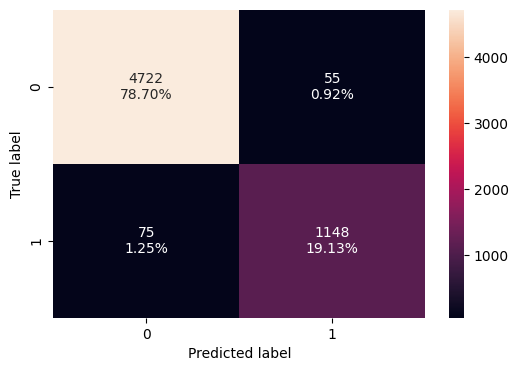

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train, y_train_pred)

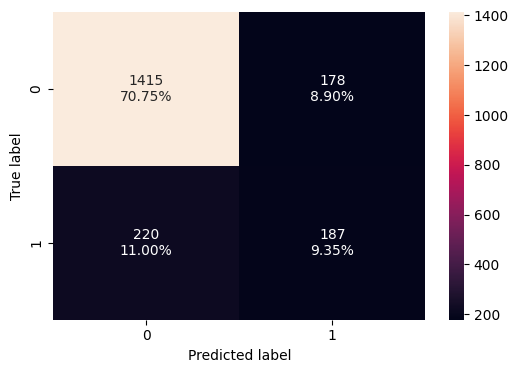

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

* Validation metrics are not that great for Adam Optimizer.
* The model is learning training data too well.

### Neural Network with Adam Optimizer and Dropout

In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# Initialize the neural network with SGD Optimizer
model_ao_do = Sequential()

# Add an input layer with 64 neurons and Relu as the activation function
model_ao_do.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Add an hidden layer with 32 neurons and Relu as the activation function
model_ao_do.add(Dense(units=32, activation='relu'))

# Add a dropout with ratio of 0.2
model_ao_do.add(Dropout(0.2))

# Add an hidden layer with 32 neurons and Relu as the activation function
model_ao_do.add(Dense(units=32, activation='relu'))

# Add a dropout with ratio of 0.1
model_ao_do.add(Dropout(0.1))


# Add an output layer with 1 neuron and Sigmoid as the activation function
# as this is a binary classification problem
model_ao_do.add(Dense(units=1, activation='sigmoid'))

In [ ]:
#Code to use Adam as the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#Choose Precision, Recall and F1 score as the metric
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

# Compile the model with loss function of binary cross entropy and F1score as the metric
model_ao_do.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)

In [ ]:
model_ao_do.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,937 (15.38 KB)

 Trainable params: 3,937 (15.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_ao_do = model_ao_do.fit(
X_train, y_train,
batch_size=32,
validation_data=(X_val,y_val),
epochs=100,
verbose=1
)

end=time.time()

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - f1_score: 0.3364 - loss: 0.5153 - precision: 0.3291 - recall: 0.0598 - val_f1_score: 0.3382 - val_loss: 0.4258 - val_precision: 0.6641 - val_recall: 0.2088
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - f1_score: 0.3364 - loss: 0.4346 - precision: 0.7007 - recall: 0.2041 - val_f1_score: 0.3382 - val_loss: 0.4186 - val_precision: 0.6645 - val_recall: 0.2531
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - f1_score: 0.3364 - loss: 0.4196 - precision: 0.6683 - recall: 0.2525 - val_f1_score: 0.3382 - val_loss: 0.4114 - val_precision: 0.6524 - val_recall: 0.2998
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - f1_score: 0.3364 - loss: 0.4094 - precision: 0.6487 - recall: 0.3029 - val_f1_score: 0.3382 - val_loss: 0.4070 - val_precision: 0.6720 - val_recall: 0.3071
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - f1_score: 0.3364 - loss: 0.3997 - precision: 0.6930 - recall: 0.3401 - val_f1_score: 0.3382 - val_lo

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  220.69838190078735


#### Plotting Training and Validation Loss

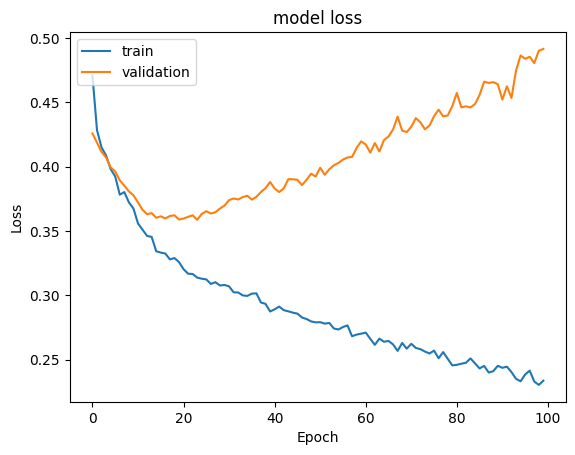

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_ao_do.history['loss'])
plt.plot(history_ao_do.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

* Training loss decreases consistently - indicating that the model is learning from the training data
* Validation loss initially follows training loss, but then flattens and increases gradually after about 30 epochs.
* Dropout has helped reduce overfitting compared to the previous model and the gap between training and validation loss is smaller.

#### Plotting the Precision, Recall and F1 Scores

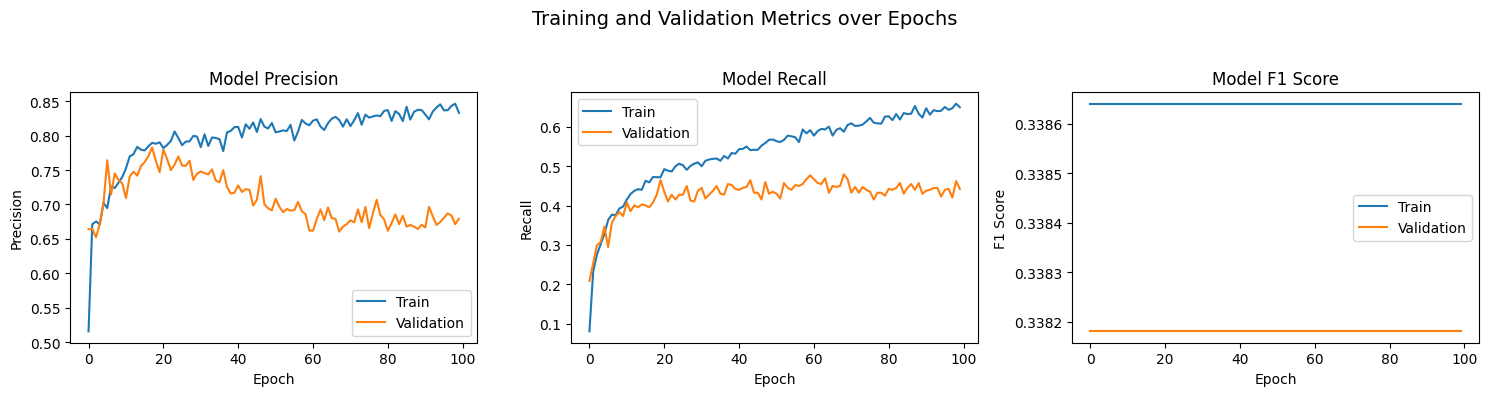

In [ ]:
plot_metrics(history_ao_do, metrics=["precision", "recall", "f1_score"])

**Precision Metric - Overfitting**
* Training precision increases steadily and levels of around 0.83, but, validation precision increases initially and then declines after about 30 epochs.
* This suggests overfitting and hence reducing generalizability

**Recall Metric - Overfitting**
* Training recall increases gradually and reaches approximately 0.65, while, validation recall improves initially and the plateaus to become noisy.
* This reflects that the model is learning to identify positives in the training data, but, struggles to generalize to unseen data.

**F1 Metric - Minor improvement, Overfitting**
* Both Training and Validation F1 scores are nearly flat, with sudden small spikes towards the end.
* The flat F1 score points towards the data imbalance.

In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_ao_do.predict(X_train)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_ao_do.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
model_name = "NN with Adam Dropout"
train_scores_df.loc[model_name] = recall_score(y_train, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4777
           1       0.90      0.69      0.78      1223

    accuracy                           0.92      6000
   macro avg       0.91      0.83      0.86      6000
weighted avg       0.92      0.92      0.92      6000



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.68      0.44      0.54       407

    accuracy                           0.84      2000
   macro avg       0.77      0.69      0.72      2000
weighted avg       0.83      0.84      0.83      2000



#### Confusion Matrix

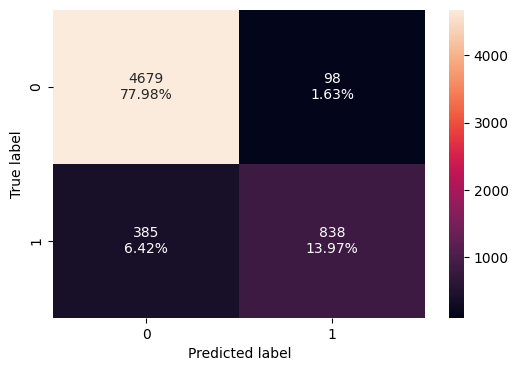

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train, y_train_pred)

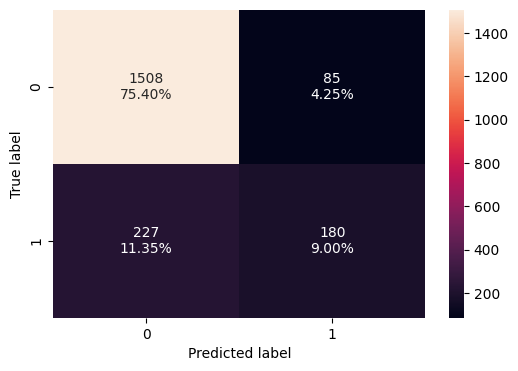

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

* Validation metrics have slightly improved but still not great for Adam Optimizer with dropouts.
* The model is still learning training data well.

### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

#### Applying SMOTE & Instantiate NN

In [ ]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(X_train_sm.shape, y_train_sm.shape)

(9554, 11) (9554,)


In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# Initialize the neural network with SGD Optimizer
model_sgd_sm = Sequential()

# Add an input layer with 128 neurons and Relu as the activation function
model_sgd_sm.add(Dense(units=128, activation='relu', input_shape=(X_train_sm.shape[1],)))

# Add an hidden layer with 64 neurons and Relu as the activation function
model_sgd_sm.add(Dense(units=64, activation='relu'))

# Add an hidden layer with 64 neurons and Relu as the activation function
model_sgd_sm.add(Dense(units=64, activation='relu'))

# Add an output layer with 1 neuron and Sigmoid as the activation function
# as this is a binary classification problem
model_sgd_sm.add(Dense(units=1, activation='sigmoid'))

In [ ]:
#Code to use SGD as the optimizer.
optimizer = tf.keras.optimizers.SGD(0.001)

#Choose Precision, Recall and F1 score as the metric
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

In [ ]:
# Compile the model with loss function of binary cross entropy and F1score as the metric
model_sgd_sm.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)

In [ ]:
model_sgd_sm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,017 (54.75 KB)

 Trainable params: 14,017 (54.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_sgd_sm = model_sgd_sm.fit(
X_train_sm, y_train_sm,
batch_size=32, ## Code to specify the batch size to use
epochs=100, ## Code to specify the number of epochs
verbose=1,
validation_data = (X_val,y_val)
)

end=time.time()

Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - f1_score: 0.6624 - loss: 0.6899 - precision: 0.5168 - recall: 0.8069 - val_f1_score: 0.3382 - val_loss: 0.6994 - val_precision: 0.2365 - val_recall: 0.7297
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6624 - loss: 0.6821 - precision: 0.5615 - recall: 0.7367 - val_f1_score: 0.3382 - val_loss: 0.6840 - val_precision: 0.2676 - val_recall: 0.6634
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6624 - loss: 0.6752 - precision: 0.6076 - recall: 0.6901 - val_f1_score: 0.3382 - val_loss: 0.6721 - val_precision: 0.3047 - val_recall: 0.6437
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6624 - loss: 0.6688 - precision: 0.6357 - recall: 0.6602 - val_f1_score: 0.3382 - val_loss: 0.6623 - val_precision: 0.3333 - val_recall: 0.6413
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6624 - loss: 0.6625 - precision: 0.6594 - recall: 0.6457 - val_f1_score: 0.3382 - val_los

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  224.04781579971313


#### Plotting Training and Validation Loss

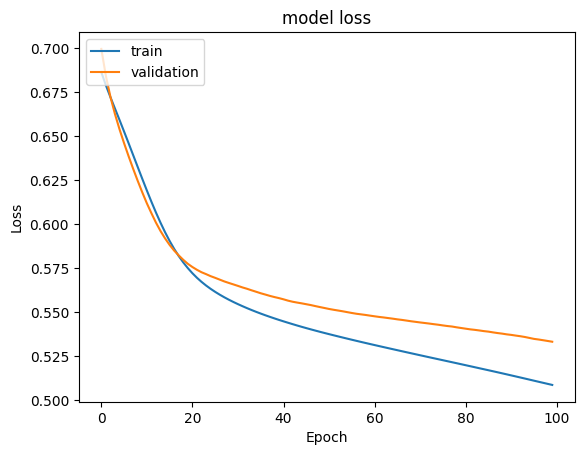

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_sgd_sm.history['loss'])
plt.plot(history_sgd_sm.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

* Both Training and Validation losses are seen decreasing smoothly. This indicates that the model is improving its performance over time, without large fluctuations.
* The losses decreasing together suggest the model is learning general patterns.
* The widening gap indicates **overfitting**

#### Plotting the Precision, Recall and F1 scores

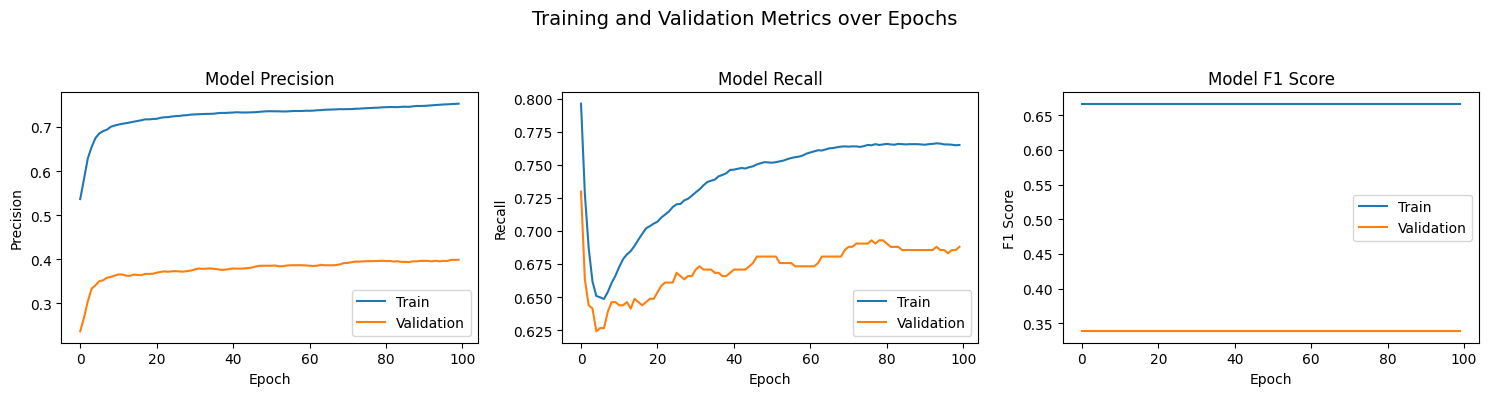

In [ ]:
plot_metrics(history_sgd_sm, metrics=["precision", "recall", "f1_score"])

**Precision Metric- Overfitting**
* Training precision increases steadily though the training and ends around 0.75, while validation precision starts very low and reaches around 0.40.
* There is a large and continuously increasing gap between the two precision metrics.

**Recall Metric - Overfitting**
* Training recall starts high and has a sudden dip before recovering and increasing steadily. Validation recall follows the initial dip but rises to a lower values with more fluctuations.
* Similar to precision, a noticeable gap develops between the two recall metrics.

**F1 Metric - Poor performance**
* There is a huge gap between the two F1 scores.
* The model has failed to generalize and performs poorly on unseen data.


In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_sgd_sm.predict(X_train_sm)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_sgd_sm.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with SGD Smote"
train_scores_df.loc[model_name] = recall_score(y_train_sm, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train_sm, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.77      0.74      0.75      4777
           1       0.75      0.77      0.76      4777

    accuracy                           0.76      9554
   macro avg       0.76      0.76      0.76      9554
weighted avg       0.76      0.76      0.76      9554



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1593
           1       0.40      0.69      0.50       407

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000



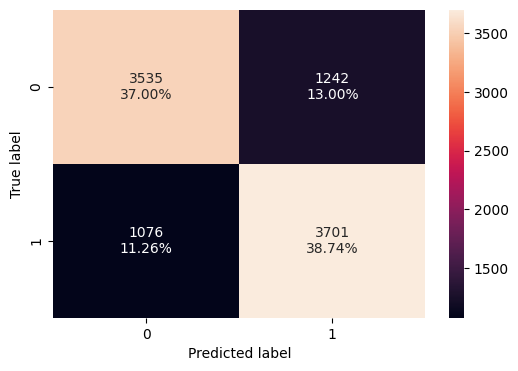

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train_sm, y_train_pred)

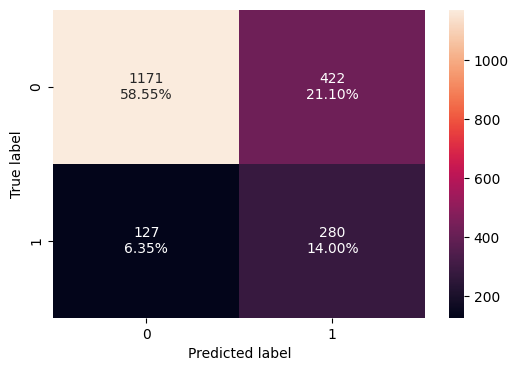

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

* The model performs well and consistently on the majority class (high precision)
* The model is finding a substantial portion of the minority class (higher recall), but, the precision is very low (high number of false positives).
* The model performs poorly on unseen data and did not generalize well (confirms overfitting).


### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

#### Instantiate NN

In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# Initialize the neural network with Adam Optimizer
model_ao_sm = Sequential()

# Add an input layer with 128 neurons and Relu as the activation function
model_ao_sm.add(Dense(units=128, activation='relu', input_shape=(X_train_sm.shape[1],)))

# Add an hidden layer with 64 neurons and Relu as the activation function
model_ao_sm.add(Dense(units=64, activation='relu'))

# Add an hidden layer with 64 neurons and Relu as the activation function
model_ao_sm.add(Dense(units=64, activation='relu'))

# Add an output layer with 1 neuron and Sigmoid as the activation function
# as this is a binary classification problem
model_ao_sm.add(Dense(units=1, activation='sigmoid'))

In [ ]:
#Code to use Adam as the optimizer.
optimizer = tf.keras.optimizers.Adam(0.001)

#Choose Precision, Recall and F1 score as the metric
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

In [ ]:
# Compile the model with loss function of binary cross entropy and F1score as the metric
model_ao_sm.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)

In [ ]:
model_ao_sm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,017 (54.75 KB)

 Trainable params: 14,017 (54.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_ao_sm = model_ao_sm.fit(
X_train_sm, y_train_sm,
batch_size=32,
epochs=100,
verbose=1,
validation_data = (X_val,y_val)
)

end = time.time()


Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - f1_score: 0.6624 - loss: 0.5889 - precision: 0.6989 - recall: 0.6485 - val_f1_score: 0.3382 - val_loss: 0.5893 - val_precision: 0.3761 - val_recall: 0.7641
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - f1_score: 0.6624 - loss: 0.4943 - precision: 0.7565 - recall: 0.7557 - val_f1_score: 0.3382 - val_loss: 0.5639 - val_precision: 0.4062 - val_recall: 0.7985
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score: 0.6624 - loss: 0.4599 - precision: 0.7786 - recall: 0.7805 - val_f1_score: 0.3382 - val_loss: 0.5460 - val_precision: 0.4225 - val_recall: 0.8108
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score: 0.6624 - loss: 0.4360 - precision: 0.7918 - recall: 0.7965 - val_f1_score: 0.3382 - val_loss: 0.5293 - val_precision: 0.4402 - val_recall: 0.8133
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - f1_score: 0.6624 - loss: 0.4167 - precision: 0.7996 - recall: 0.8076 - val_f1_score: 0.3382 - val_lo

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  252.97596740722656


#### Plotting Training and Validation Loss

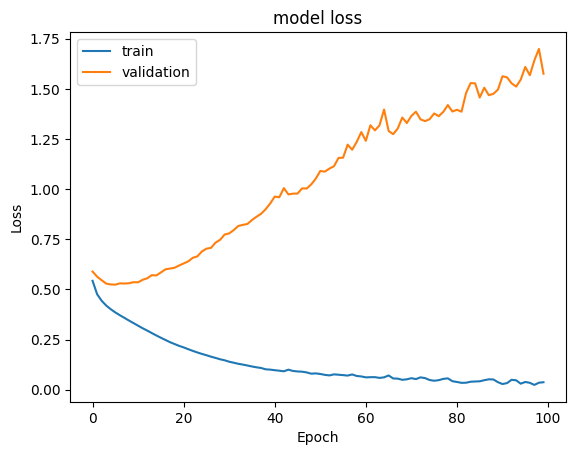

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_ao_sm.history['loss'])
plt.plot(history_ao_sm.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

* Training model loss decreases rapidly and ends close to 0. This indicates that Adam Optimizer if effectively minimizing the loss function and fitting the training well.
* The Validation loss starts in a similar fashion and then starts increasing rapidly and widens the gap. This indicates overfitting.

#### Plotting the Precision, Recall and F1 Scores

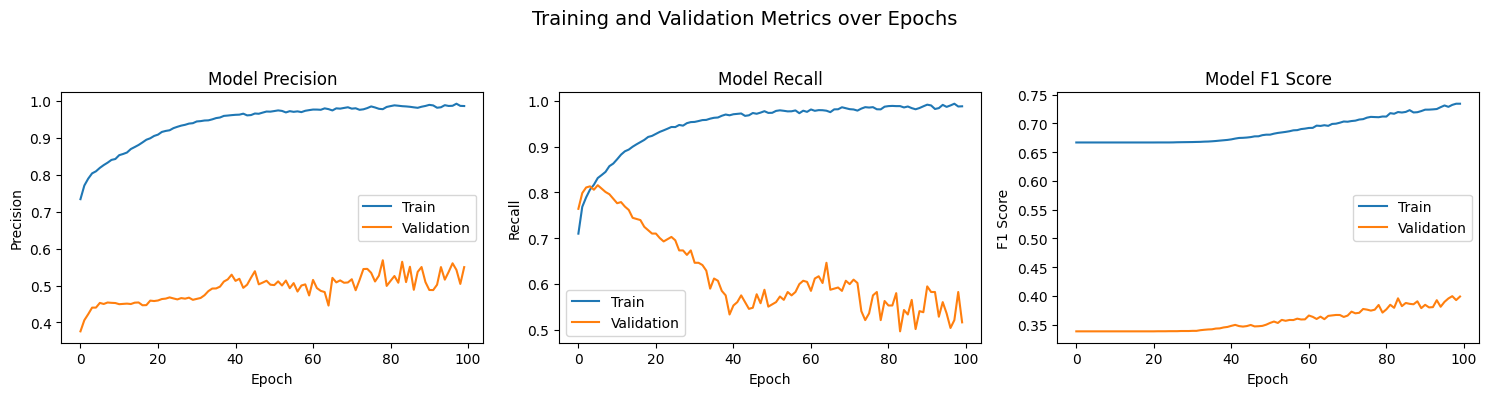

In [ ]:
plot_metrics(history_ao_sm, metrics=["precision", "recall", "f1_score"])

**Precision Metric- Overfitting**
* The Training precision increases rapidly and becomes very precise on the training data.
* The Validation precision increases initially and then plateaus to a relatively low value after fluctuations.
* High precision on training data does not translate to validation data.

**Recall Metric- Too specific to training dataset**
* Training recall increases steadily and plateaus near 1 - finding all relevant instances.
* Validation recall starts high and then decreases rapidly with fluctuations to a lower level.
* Huge gap has developed between training and validation recall.

**F1 Metric- Poor performance**
* A huge gap exists between the training and validation scores.
* The model is not generalizing well to unseen data.

In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_ao_sm.predict(X_train_sm)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [ True],
       [ True]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_ao_sm.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
model_name = "NN with Adam Smote"
train_scores_df.loc[model_name] = recall_score(y_train_sm, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

In [ ]:
#print(train_scores_df)
#print(val_scores_df)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train_sm, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4777
           1       0.99      0.99      0.99      4777

    accuracy                           0.99      9554
   macro avg       0.99      0.99      0.99      9554
weighted avg       0.99      0.99      0.99      9554



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1593
           1       0.55      0.52      0.53       407

    accuracy                           0.82      2000
   macro avg       0.71      0.70      0.71      2000
weighted avg       0.81      0.82      0.81      2000



#### Confusion Matrix

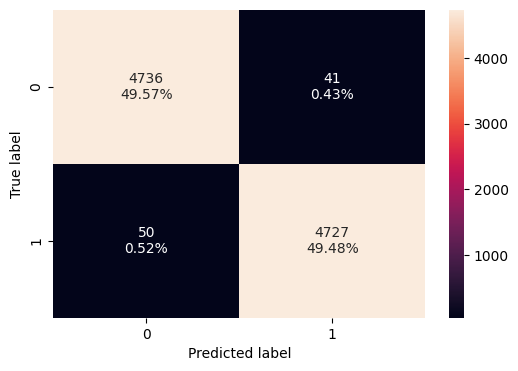

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train_sm, y_train_pred)

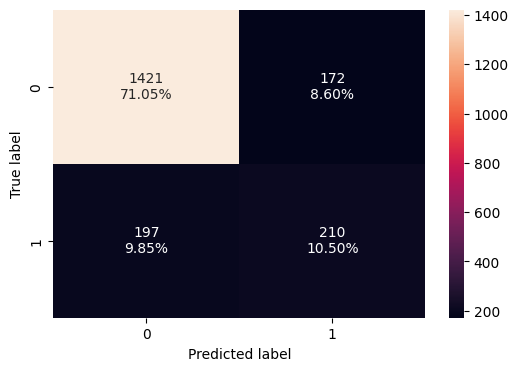

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

* The performance drop significantly on the validation set, especially for call "1"  the minority class.
* The model learns the training data patterns well, but does not translate to unseen data.
* Overfitting is confirmed (as observed before)

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

#### Instantiate NN

In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
DROPOUT = 0.5

In [ ]:
# Initialize the neural network with Adam Optimizer
model_ao_sm_do = Sequential()

# Add an input layer with 64 neurons and Relu as the activation function
model_ao_sm_do.add(Dense(units=64, activation='relu', input_shape=(X_train_sm.shape[1],)))

# Add dropout rate
model_ao_sm_do.add(Dropout(DROPOUT))

# Add an hidden layer with 32 neurons and Relu as the activation function
model_ao_sm_do.add(Dense(units=32, activation='relu'))

# Add dropout rate
model_ao_sm_do.add(Dropout(DROPOUT))

# Add an hidden layer with 16 neurons and Relu as the activation function
model_ao_sm_do.add(Dense(units=16, activation='relu'))

# Add an output layer with 1 neuron and Sigmoid as the activation function
# as this is a binary classification problem
model_ao_sm_do.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# Use Adam as the optimizer
optimizer = tf.keras.optimizers.Adam(0.001)

#Choose Precision, Recall and F1 score as the metric
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

In [ ]:
# Compile the model with loss function of binary cross entropy and F1score as the metric
model_ao_sm_do.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)

In [ ]:
model_ao_sm_do.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

history_ao_sm_do = model_ao_sm_do.fit(
    X_train_sm, y_train_sm,
    batch_size=32,
    epochs=33,
    verbose=1,
    validation_data = (X_val,y_val)
)

end = time.time()

Epoch 1/33
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - f1_score: 0.6624 - loss: 0.6798 - precision: 0.5494 - recall: 0.6388 - val_f1_score: 0.3382 - val_loss: 0.5651 - val_precision: 0.3639 - val_recall: 0.6929
Epoch 2/33
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_score: 0.6624 - loss: 0.6061 - precision: 0.6747 - recall: 0.6994 - val_f1_score: 0.3382 - val_loss: 0.5479 - val_precision: 0.3724 - val_recall: 0.7027
Epoch 3/33
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_score: 0.6624 - loss: 0.5904 - precision: 0.6829 - recall: 0.7228 - val_f1_score: 0.3382 - val_loss: 0.5712 - val_precision: 0.3690 - val_recall: 0.7199
Epoch 4/33
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - f1_score: 0.6624 - loss: 0.5800 - precision: 0.6938 - recall: 0.7341 - val_f1_score: 0.3382 - val_loss: 0.5596 - val_precision: 0.3766 - val_recall: 0.7052
Epoch 5/33
299/299 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - f1_score: 0.6624 - loss: 0.5742 - precision: 0.7002 - recall: 0.7340 - val_f1_score: 0.3382 - val_loss: 0.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  76.79849982261658


#### Plotting Training and Validation Loss

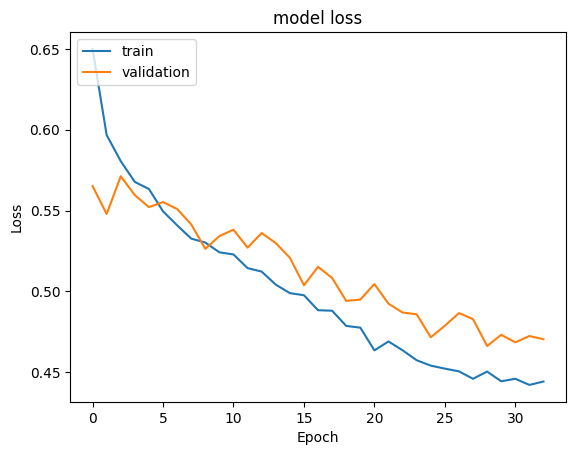

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_ao_sm_do.history['loss'])
plt.plot(history_ao_sm_do.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

* Model is learning well on training data.
* It is not generalizing well on unseen data despite dropout regularization.
* SMOTE maybe introducing synthetic noise that the model is overfitting to.

#### Plotting the Precision, Recall and F1 scores

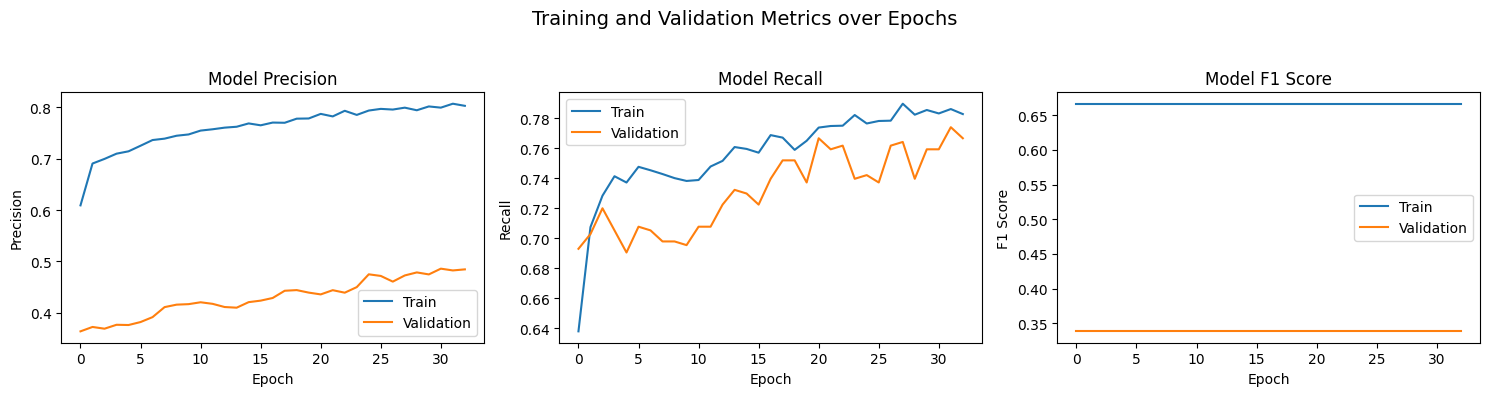

In [ ]:
plot_metrics(history_ao_sm_do, metrics=["precision", "recall", "f1_score"])

**Precision Metric -**
* Training precision increases steadily
* Validation precision rises and plateaus at around 0.5

**Recall Metric -**
* Training recall is high and keep improving
* Validation recall improves initially and then flattens and dips
* Another sign of overfitting

**F1 Metric -**
* F1 scores confirm overfitting of data with a consistent difference between training and validation datasets.
* Validation score is low and flat, the model has poor generalization to the minority class despite using SMOTE and dropouts with Adam Optimizer.

In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_ao_sm_do.predict(X_train_sm)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_ao_sm_do.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with Adam Smote & Dropout"
train_scores_df.loc[model_name] = recall_score(y_train_sm, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train_sm, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.80      0.82      4777
           1       0.81      0.84      0.82      4777

    accuracy                           0.82      9554
   macro avg       0.82      0.82      0.82      9554
weighted avg       0.82      0.82      0.82      9554



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.79      0.86      1593
           1       0.48      0.77      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.72      2000
weighted avg       0.84      0.79      0.80      2000



#### Confusion Matrix

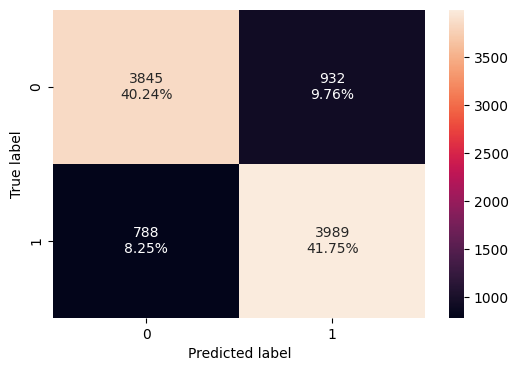

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train_sm, y_train_pred)

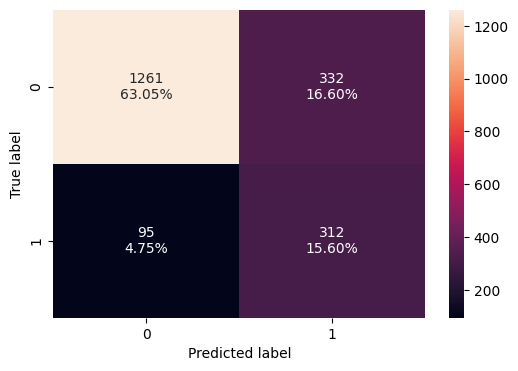

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, Dropout and Early Stopping

#### Instantiate NN

In [ ]:
# Initialization
backend.clear_session()
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
DROPOUT = 0.5

In [ ]:
# Initialize the neural network with Adam Optimizer
model_ao_sm_do_es = Sequential()

# Add an input layer with 64 neurons and Relu as the activation function
model_ao_sm_do_es.add(Dense(units=64, activation='relu', input_shape=(X_train_sm.shape[1],)))

# Add dropout rate
model_ao_sm_do_es.add(Dropout(DROPOUT))

# Add an hidden layer with 32 neurons and Relu as the activation function
model_ao_sm_do_es.add(Dense(units=32, activation='relu'))

# Add dropout rate
model_ao_sm_do_es.add(Dropout(DROPOUT))

# Add an hidden layer with 16 neurons and Relu as the activation function
model_ao_sm_do_es.add(Dense(units=16, activation='relu'))

# Add an output layer with 1 neuron and Sigmoid as the activation function
# as this is a binary classification problem
model_ao_sm_do_es.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# Use Adam as the optimizer
optimizer = tf.keras.optimizers.Adam(0.001)

#Choose Precision, Recall and F1 score as the metric
metric = [Precision(), Recall(), keras.metrics.F1Score(average = 'macro')]

In [ ]:
# Compile the model with loss function of binary cross entropy and F1score as the metric
model_ao_sm_do_es.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=metric)

In [ ]:
# Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    verbose=1,
    patience=10,
    mode='min',
    restore_best_weights=True
)

In [ ]:
model_ao_sm_do.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,181 (39.77 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,788 (26.52 KB)

In [ ]:
start = time.time()

history_ao_sm_do_es = model_ao_sm_do_es.fit(
    X_train_sm, y_train_sm,
    batch_size=32,
    epochs=100,
    verbose=1,
    validation_data = (X_val,y_val),
    callbacks=[early_stopping]
)

end = time.time()

Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - f1_score: 0.6624 - loss: 0.6798 - precision: 0.5494 - recall: 0.6388 - val_f1_score: 0.3382 - val_loss: 0.5651 - val_precision: 0.3639 - val_recall: 0.6929
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - f1_score: 0.6624 - loss: 0.6061 - precision: 0.6747 - recall: 0.6994 - val_f1_score: 0.3382 - val_loss: 0.5479 - val_precision: 0.3724 - val_recall: 0.7027
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score: 0.6624 - loss: 0.5904 - precision: 0.6829 - recall: 0.7228 - val_f1_score: 0.3382 - val_loss: 0.5712 - val_precision: 0.3690 - val_recall: 0.7199
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - f1_score: 0.6624 - loss: 0.5800 - precision: 0.6938 - recall: 0.7341 - val_f1_score: 0.3382 - val_loss: 0.5596 - val_precision: 0.3766 - val_recall: 0.7052
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - f1_score: 0.6624 - loss: 0.5742 - precision: 0.7002 - recall: 0.7340 - val_f1_score: 0.3382 - val_lo

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  163.1056649684906


#### Plotting Training and Validation Loss

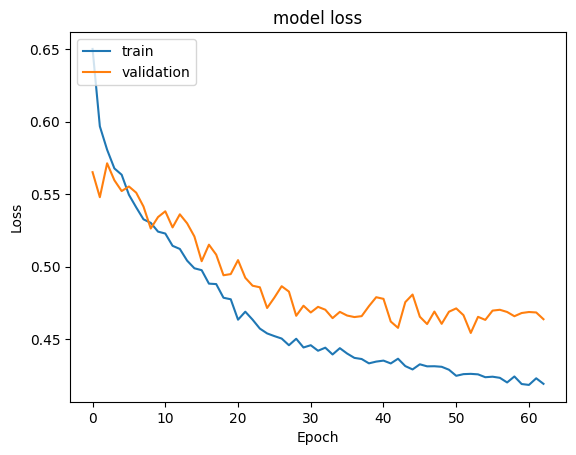

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_ao_sm_do_es.history['loss'])
plt.plot(history_ao_sm_do_es.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

#### Plotting the Precision, Recall and F1 Scores

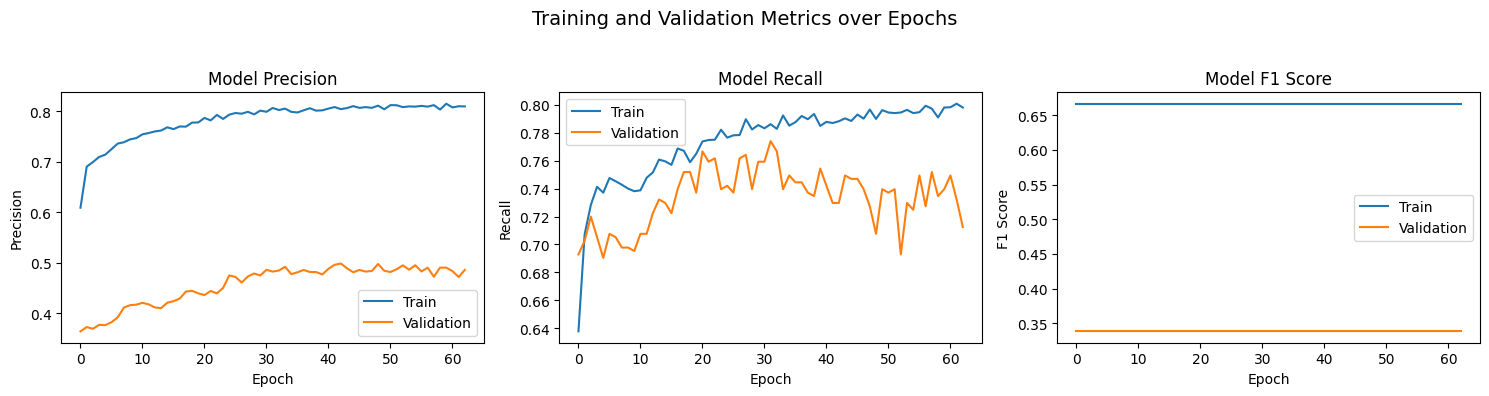

In [ ]:
plot_metrics(history_ao_sm_do_es, metrics=["precision", "recall", "f1_score"])

In [ ]:
#Predicting the results using best as a threshold for training data
y_train_pred = model_ao_sm_do_es.predict(X_train_sm)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
#Predicting the results using best as a threshold for validation data
y_val_pred = model_ao_sm_do_es.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with Adam Smote, Drop, Early Stop"

train_scores_df.loc[model_name] = recall_score(y_train_sm, y_train_pred)
val_scores_df.loc[model_name] = recall_score(y_val, y_val_pred)

#### Classification Report

In [ ]:
#Training classification report
cr = classification_report(y_train_sm, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      4777
           1       0.83      0.82      0.83      4777

    accuracy                           0.83      9554
   macro avg       0.83      0.83      0.83      9554
weighted avg       0.83      0.83      0.83      9554



In [ ]:
#Validation classification report
cr = classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.82      0.86      1593
           1       0.49      0.69      0.58       407

    accuracy                           0.79      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.79      0.81      2000



#### Confusion Matrix

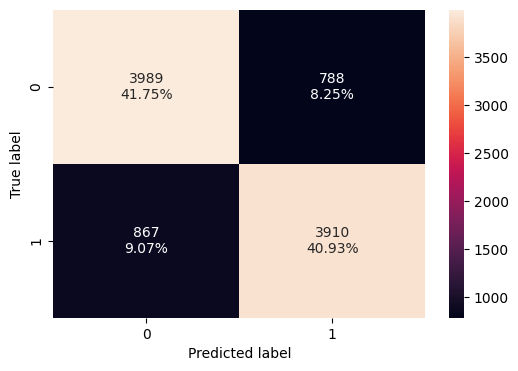

In [ ]:
# Confusion matrix for training
make_confusion_matrix(y_train_sm, y_train_pred)

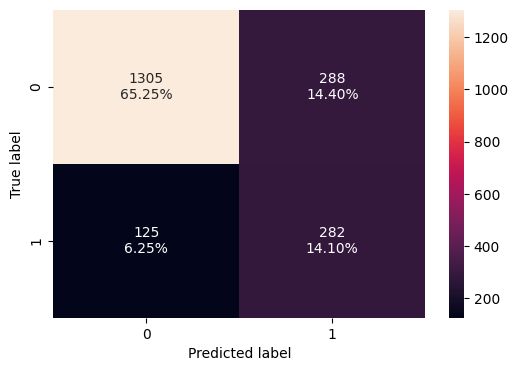

In [ ]:
# Confusion matrix for validation
make_confusion_matrix(y_val, y_val_pred)

## Model Performance Comparison and Final Model Selection

In [ ]:
df = pd.concat([train_scores_df, val_scores_df, (train_scores_df - val_scores_df)], axis=1)
df.columns = ['Train Recall', 'Validation Recall', 'Delta']
df

,Train Recall,Validation Recall,Delta
NN with SGD,0.206,0.187,0.019
NN with Adam,0.939,0.459,0.479
NN with Adam Dropout,0.685,0.442,0.243
NN with SGD Smote,0.775,0.688,0.087
NN with Adam Smote,0.990,0.516,0.474
NN with Adam Smote & Dropout,0.835,0.767,0.068
"NN with Adam Smote, Drop, Early Stop",0.819,0.693,0.126


* We can choose the model with **Balanced Data (SMOTE), Adam Optimizer and Dropouts** based on the table above.

#### Model Performance on Test data

In [ ]:
# Model chosen is model_ao_sm_do
y_test_pred = model_ao_sm_do.predict(X_test)
y_test_pred = (y_test_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
#Classification report
cr = classification_report(y_test, y_test_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.77      0.84      1593
           1       0.46      0.75      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.77      0.79      2000



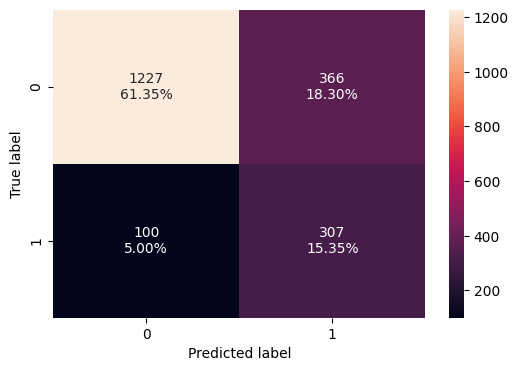

In [ ]:
#Confusion Matrix for test data
make_confusion_matrix(y_test, y_test_pred)

* Good Minority Recall: The primary success of this model (maybe due to SMOTE) is its ability to find a large portion (77%) of the minority class instances (good Recall for Class 1). It misses relatively few actual Class 1 cases (only 93 FN).
* Poor Minority Precision: The major weakness is the high number of False Positives for Class 1. The model frequently misclassifies majority class instances (Class 0) as belonging to the minority class (Class 1), leading to very low precision (0.44) for Class 1.
* The model achieves high recall for the minority class at the significant cost of precision for that same class.

* Moderate Majority Class performance: The model performed decent on the majority class (Class 0), achieving high Precision (0.93) but only moderate Recall (0.75). The lower recall indicates that a noticeable portion (25%) of Class 0 instances were misclassified, primarily as Class 1 (contributing to Class 1's low precision).

* Overfitting is still observed with balanced training data. The learnings did not translate well to unseen imbalance data.

* Impact of SMOTE and Dropout: While SMOTE successfully forced the model to learn the minority class (leading to high recall), training on perfectly balanced, potentially synthetic data likely contributed heavily to the overfitting. The Dropout (0.5) used was insufficient to prevent this severe overfitting or to improve the poor precision on the imbalanced test set.

## Actionable Insights and Business Recommendations

**Key Findings/Actionable Insights**
* Churn Risk Is Influenced by Age, Credit Score, and Account Activity
  * Older customers and those with lower credit scores are more likely to churn.
  * Customers marked as inactive (IsActiveMember = 0) show a significantly higher churn rate.
  * Geography plays a role — churn patterns vary across countries (e.g., higher churn in Germany).

* Balance and Products Held Are Not Strong Retention Factors Alone
  * Customers with high balances are still churning, indicating that balance alone is not a loyalty indicator.
  * Having only one product is common among churners - cross-selling may improve retention.

* Credit Card Ownership Shows Weak Correlation to Retention
  * The presence of a credit card does not  appear to strongly affect churn.
  * Offering a card is not a strong enough hook — it should be combined with other benefits.

* Machine Learning Models Provide High Predictive Accuracy
  * Several models achieved high precision and recall, especially using the Adam optimizer.
  * With added regularization and dropout, overfitting was reduced, improving real-world generalization.


**Business Recommendations**
1. Proactively Engage High-Risk Segments
  * Target older, inactive customers with acceptable credit scores for retention campaigns.
  * Introduce personal finance coaching or customized offerings for these segments.

2. Geography Specific Strategies
  * Analyze regional churn behavior deeper (e.g., why Germany sees higher churn).
  * Create geography-personalized loyalty programs or local customer service improvements.

3. Enhance Product Bundling & Cross-Sell Offers
  * Promote bundles (e.g., savings + investment products) to customers with only one product.
  * Provide incentives for expanding their portfolio — perhaps gamified loyalty tiers.

4. Track and Act on Activity Signals
  * Use IsActiveMember as a live signal for customer health scoring.
  * Reach out early to inactive users before they churn — with nudges or benefit reminders.

5. Optimize Credit Scoring and Customer Education
  * Educate customers on how improving their credit score can enhance their financial options.
  * Offer free credit score monitoring within banking apps to increase stickiness.




<font size=6 color='blue'>Power Ahead</font>
___